<a href="https://colab.research.google.com/github/Amyriki/PHF14-pan-cancer-analysis/blob/main/01_PHF14_LUAD_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# PHF14 pan-cancer analysis — Data preparation

## Goal

Prepare consistently processed TCGA gene-expression datasets for a
PHF14-centered pan-cancer analysis.

### Initial cancer types

- LUAD — Lung adenocarcinoma
- LUSC — Lung squamous cell carcinoma
- STAD — Stomach adenocarcinoma
- PAAD — Pancreatic adenocarcinoma
- UCEC — Uterine corpus endometrial carcinoma

## Principle

All cancer types will be processed using the same data source,
sample-selection criteria, expression units, and gene identifiers
to ensure that downstream comparisons are reproducible.

In [17]:
# TCGA projects included in the initial pan-cancer analysis

projects = {
    "LUAD": "TCGA-LUAD",
    "LUSC": "TCGA-LUSC",
    "STAD": "TCGA-STAD",
    "PAAD": "TCGA-PAAD",
    "UCEC": "TCGA-UCEC"
}

for cancer, project in projects.items():
    print(f"{cancer}: {project}")

LUAD: TCGA-LUAD
LUSC: TCGA-LUSC
STAD: TCGA-STAD
PAAD: TCGA-PAAD
UCEC: TCGA-UCEC


In [18]:
import requests
import json

# Test the GDC API using TCGA-LUAD

gdc_files_endpoint = "https://api.gdc.cancer.gov/files"

filters = {
    "op": "and",
    "content": [
        {
            "op": "in",
            "content": {
                "field": "cases.project.project_id",
                "value": ["TCGA-LUAD"]
            }
        },
        {
            "op": "in",
            "content": {
                "field": "data_type",
                "value": ["Gene Expression Quantification"]
            }
        },
        {
            "op": "in",
            "content": {
                "field": "analysis.workflow_type",
                "value": ["STAR - Counts"]
            }
        }
    ]
}

params = {
    "filters": json.dumps(filters),
    "format": "JSON",
    "size": "5",
    "fields": "file_id,file_name,data_type,analysis.workflow_type"
}

response = requests.get(gdc_files_endpoint, params=params)

print("Status code:", response.status_code)

Status code: 200


In [19]:
# Inspect the files returned by GDC

data = response.json()

print("Total matching files:", data["data"]["pagination"]["total"])
print()

for hit in data["data"]["hits"]:
    print("File name:", hit["file_name"])
    print("File ID:", hit["file_id"])
    print("Workflow:", hit["analysis"]["workflow_type"])
    print("-" * 50)

Total matching files: 601

File name: 9a5e0fa6-a785-4d8e-bca5-43e02a3965bf.rna_seq.augmented_star_gene_counts.tsv
File ID: 9a64a124-9787-4378-ba01-b79aa183f25f
Workflow: STAR - Counts
--------------------------------------------------
File name: f48a9d85-c3c7-40bc-9215-760ba3b8fa60.rna_seq.augmented_star_gene_counts.tsv
File ID: cab5b00a-9cf2-4e1f-b2f3-93d27b73631e
Workflow: STAR - Counts
--------------------------------------------------
File name: ee030015-242a-4dd1-b43c-2c97d5d365d9.rna_seq.augmented_star_gene_counts.tsv
File ID: 9a6d8661-241e-4a3e-a6fa-e2eb1962b758
Workflow: STAR - Counts
--------------------------------------------------
File name: 555b77b9-d686-4f0e-a099-25bd5715a5e9.rna_seq.augmented_star_gene_counts.tsv
File ID: f6582ef5-5f6d-41d7-850a-614257c9e3b2
Workflow: STAR - Counts
--------------------------------------------------
File name: 27e24fc6-af40-4152-8424-a9d365c717d9.rna_seq.augmented_star_gene_counts.tsv
File ID: 4b2e6f07-59e6-47c0-85ea-1e73f3354a01
Workflow

In [20]:
# Restrict the analysis to primary tumor samples

primary_tumor_filters = {
    "op": "and",
    "content": [
        {
            "op": "in",
            "content": {
                "field": "cases.project.project_id",
                "value": ["TCGA-LUAD"]
            }
        },
        {
            "op": "in",
            "content": {
                "field": "data_type",
                "value": ["Gene Expression Quantification"]
            }
        },
        {
            "op": "in",
            "content": {
                "field": "analysis.workflow_type",
                "value": ["STAR - Counts"]
            }
        },
        {
            "op": "in",
            "content": {
                "field": "cases.samples.sample_type",
                "value": ["Primary Tumor"]
            }
        }
    ]
}

params_primary = {
    "filters": json.dumps(primary_tumor_filters),
    "format": "JSON",
    "size": "5",
    "fields": "file_id,file_name,cases.submitter_id,cases.samples.sample_type"
}

response_primary = requests.get(
    gdc_files_endpoint,
    params=params_primary
)

primary_data = response_primary.json()

print("Status code:", response_primary.status_code)
print(
    "LUAD primary-tumor STAR-Counts files:",
    primary_data["data"]["pagination"]["total"]
)

Status code: 200
LUAD primary-tumor STAR-Counts files: 540


In [21]:
# Download one LUAD primary-tumor STAR-Counts file

first_file = primary_data["data"]["hits"][0]

file_id = first_file["file_id"]
file_name = first_file["file_name"]

download_url = f"https://api.gdc.cancer.gov/data/{file_id}"

r = requests.get(download_url)
r.raise_for_status()

with open(file_name, "wb") as f:
    f.write(r.content)

print("Downloaded:")
print(file_name)
print(f"Size: {len(r.content) / 1024:.1f} KB")

Downloaded:
9a5e0fa6-a785-4d8e-bca5-43e02a3965bf.rna_seq.augmented_star_gene_counts.tsv
Size: 4144.8 KB


In [22]:
# Inspect the STAR-Counts file

sample_expression = pd.read_csv(
    file_name,
    sep="\t",
    comment="#"
)

print("Shape:", sample_expression.shape)
print("Columns:")
print(sample_expression.columns.tolist())

sample_expression.head(10)

Shape: (60664, 9)
Columns:
['gene_id', 'gene_name', 'gene_type', 'unstranded', 'stranded_first', 'stranded_second', 'tpm_unstranded', 'fpkm_unstranded', 'fpkm_uq_unstranded']


,gene_id,gene_name,gene_type,unstranded,stranded_first,stranded_second,tpm_unstranded,fpkm_unstranded,fpkm_uq_unstranded
0,N_unmapped,NaN,NaN,1546926,1546926,1546926,NaN,NaN,NaN
1,N_multimapping,NaN,NaN,4224903,4224903,4224903,NaN,NaN,NaN
2,N_noFeature,NaN,NaN,2811456,24132202,24160298,NaN,NaN,NaN
3,N_ambiguous,NaN,NaN,4477700,1140949,1137405,NaN,NaN,NaN
4,ENSG00000000003.15,TSPAN6,protein_coding,2834,1459,1375,48.3545,16.4624,15.4946
5,ENSG00000000005.6,TNMD,protein_coding,2,1,1,0.1049,0.0357,0.0336
6,ENSG00000000419.13,DPM1,protein_coding,1307,658,650,83.8066,28.5322,26.8548
7,ENSG00000000457.14,SCYL3,protein_coding,715,590,562,8.0397,2.7371,2.5762
8,ENSG00000000460.17,C1orf112,protein_coding,285,384,376,3.6947,1.2579,1.1839
9,ENSG00000000938.13,FGR,protein_coding,1045,519,527,23.9140,8.1416,7.6629


In [23]:
# Show all columns in the STAR-Counts file

for i, col in enumerate(sample_expression.columns):
    print(i, col)

0 gene_id
1 gene_name
2 gene_type
3 unstranded
4 stranded_first
5 stranded_second
6 tpm_unstranded
7 fpkm_unstranded
8 fpkm_uq_unstranded


In [24]:
# Retrieve metadata for all LUAD primary-tumor files

params_all = {
    "filters": json.dumps(primary_tumor_filters),
    "format": "JSON",
    "size": "1000",
    "fields": (
        "file_id,file_name,"
        "cases.submitter_id,"
        "cases.samples.submitter_id,"
        "cases.samples.sample_type"
    )
}

response_all = requests.get(
    gdc_files_endpoint,
    params=params_all
)

luad_files = response_all.json()["data"]["hits"]

print("Files retrieved:", len(luad_files))

Files retrieved: 540


In [25]:
# Inspect patient and sample identifiers

records = []

for hit in luad_files:
    case = hit["cases"][0]
    sample = case["samples"][0]

    records.append({
        "file_id": hit["file_id"],
        "file_name": hit["file_name"],
        "patient_id": case["submitter_id"],
        "sample_id": sample["submitter_id"],
        "sample_type": sample["sample_type"]
    })

luad_metadata = pd.DataFrame(records)

print("Files:", len(luad_metadata))
print("Unique samples:", luad_metadata["sample_id"].nunique())
print("Unique patients:", luad_metadata["patient_id"].nunique())

luad_metadata.head()

Files: 540
Unique samples: 529
Unique patients: 517


,file_id,file_name,patient_id,sample_id,sample_type
0,9a64a124-9787-4378-ba01-b79aa183f25f,9a5e0fa6-a785-4d8e-bca5-43e02a3965bf.rna_seq.a...,TCGA-44-6147,TCGA-44-6147-01A,Primary Tumor
1,cab5b00a-9cf2-4e1f-b2f3-93d27b73631e,f48a9d85-c3c7-40bc-9215-760ba3b8fa60.rna_seq.a...,TCGA-38-4631,TCGA-38-4631-01A,Primary Tumor
2,9a6d8661-241e-4a3e-a6fa-e2eb1962b758,ee030015-242a-4dd1-b43c-2c97d5d365d9.rna_seq.a...,TCGA-44-6147,TCGA-44-6147-01B,Primary Tumor
3,f6582ef5-5f6d-41d7-850a-614257c9e3b2,555b77b9-d686-4f0e-a099-25bd5715a5e9.rna_seq.a...,TCGA-50-6597,TCGA-50-6597-01A,Primary Tumor
4,4b2e6f07-59e6-47c0-85ea-1e73f3354a01,27e24fc6-af40-4152-8424-a9d365c717d9.rna_seq.a...,TCGA-55-8511,TCGA-55-8511-01A,Primary Tumor


In [26]:
# Identify patients with multiple primary-tumor samples

patient_counts = (
    luad_metadata
    .groupby("patient_id")["sample_id"]
    .nunique()
    .sort_values(ascending=False)
)

print("Patients with >1 primary-tumor sample:")
print((patient_counts > 1).sum())

patient_counts[patient_counts > 1]

Patients with >1 primary-tumor sample:
12


,sample_id
patient_id,
TCGA-44-2656,2
TCGA-44-2662,2
TCGA-44-2665,2
TCGA-44-2666,2
TCGA-44-2668,2
TCGA-44-3917,2
TCGA-44-3918,2
TCGA-44-4112,2
TCGA-44-5645,2


In [27]:
# Inspect duplicated patients

duplicated_patients = patient_counts[
    patient_counts > 1
].index

luad_metadata[
    luad_metadata["patient_id"].isin(duplicated_patients)
].sort_values(["patient_id", "sample_id"])[
    ["patient_id", "sample_id", "file_id"]
]

,patient_id,sample_id,file_id
50,TCGA-44-2656,TCGA-44-2656-01A,201c0fbc-124c-4ef0-b767-393443a47892
125,TCGA-44-2656,TCGA-44-2656-01A,77819b24-ea90-427b-8a99-c9a90417c903
127,TCGA-44-2656,TCGA-44-2656-01B,c4bcc6b0-96a1-452b-9169-b4a16bcb9403
374,TCGA-44-2662,TCGA-44-2662-01A,946692ad-ed52-4bd8-85ac-efe5178b15b4
375,TCGA-44-2662,TCGA-44-2662-01A,2bf191f1-b880-427e-996c-0e75df13d738
373,TCGA-44-2662,TCGA-44-2662-01B,1ab1279d-7ccd-4450-8de8-9987bf6627dd
297,TCGA-44-2665,TCGA-44-2665-01A,e8da0b02-8b75-4a85-b91a-6f8d1582a95c
350,TCGA-44-2665,TCGA-44-2665-01A,ba8aebd8-07de-46c0-a28f-b2408c36f07f
306,TCGA-44-2665,TCGA-44-2665-01B,fc732523-d387-4a1d-ab81-34e44e869bac
328,TCGA-44-2666,TCGA-44-2666-01A,36c7d3a4-193f-49fd-b367-e7aacc4eebe2


In [28]:
print("Files:", len(luad_metadata))
print("Unique sample IDs:", luad_metadata["sample_id"].nunique())
print("Unique patients:", luad_metadata["patient_id"].nunique())

print(
    "Patients with multiple primary-tumor samples:",
    (patient_counts > 1).sum()
)

print(
    "Sample IDs represented by multiple files:",
    luad_metadata["sample_id"].duplicated(keep=False).groupby(
        luad_metadata["sample_id"]
    ).any().sum()
)

Files: 540
Unique sample IDs: 529
Unique patients: 517
Patients with multiple primary-tumor samples: 12
Sample IDs represented by multiple files: 11


In [29]:
# Inspect metadata for duplicated sample IDs

duplicate_sample_ids = (
    luad_metadata["sample_id"]
    .value_counts()
    .loc[lambda x: x > 1]
    .index
)

duplicate_files = luad_metadata[
    luad_metadata["sample_id"].isin(duplicate_sample_ids)
]

duplicate_files[
    ["patient_id", "sample_id", "file_id", "file_name"]
].sort_values(["sample_id", "file_id"])

,patient_id,sample_id,file_id,file_name
50,TCGA-44-2656,TCGA-44-2656-01A,201c0fbc-124c-4ef0-b767-393443a47892,b556d35a-4855-4e56-9e02-5fc939722169.rna_seq.a...
125,TCGA-44-2656,TCGA-44-2656-01A,77819b24-ea90-427b-8a99-c9a90417c903,b307f8c5-d21f-42ae-9771-07126d58999e.rna_seq.a...
375,TCGA-44-2662,TCGA-44-2662-01A,2bf191f1-b880-427e-996c-0e75df13d738,33e0a8b2-3e7e-46da-b5ef-76463308d3b9.rna_seq.a...
374,TCGA-44-2662,TCGA-44-2662-01A,946692ad-ed52-4bd8-85ac-efe5178b15b4,883ef55a-e8c0-4774-a298-d2bfeaeeae4b.rna_seq.a...
350,TCGA-44-2665,TCGA-44-2665-01A,ba8aebd8-07de-46c0-a28f-b2408c36f07f,77b82c3f-e20c-4e3b-a55c-08af359bbb6e.rna_seq.a...
297,TCGA-44-2665,TCGA-44-2665-01A,e8da0b02-8b75-4a85-b91a-6f8d1582a95c,af649713-fb41-496a-a94b-3691d202c1c8.rna_seq.a...
328,TCGA-44-2666,TCGA-44-2666-01A,36c7d3a4-193f-49fd-b367-e7aacc4eebe2,cc1646da-11b3-40c7-b35e-1206f4517b36.rna_seq.a...
403,TCGA-44-2666,TCGA-44-2666-01A,52363b7b-f157-4fbe-8388-169b6152c9fe,655b5152-d150-4b2a-b7cc-ef70dc0b2256.rna_seq.a...
287,TCGA-44-2668,TCGA-44-2668-01A,5f2d965a-25df-4736-a675-efeb59341a04,9a54be5e-6201-4beb-9689-289b9849756e.rna_seq.a...
315,TCGA-44-2668,TCGA-44-2668-01A,f47927c5-e1e9-4152-9817-79aa6e64111a,58e4f0e6-3b0f-4370-8abf-0b4d533672c5.rna_seq.a...


In [30]:
duplicate_files.groupby("sample_id").size().sort_values(ascending=False)

,0
sample_id,
TCGA-44-2656-01A,2
TCGA-44-2662-01A,2
TCGA-44-2665-01A,2
TCGA-44-2666-01A,2
TCGA-44-2668-01A,2
TCGA-44-3918-01A,2
TCGA-44-4112-01A,2
TCGA-44-5645-01A,2
TCGA-44-6146-01A,2


In [31]:
# Inspect detailed metadata for one duplicated sample

example_sample = "TCGA-44-2656-01A"

example_file_ids = duplicate_files.loc[
    duplicate_files["sample_id"] == example_sample,
    "file_id"
].tolist()

print("Sample:", example_sample)
print("File IDs:", example_file_ids)

Sample: TCGA-44-2656-01A
File IDs: ['201c0fbc-124c-4ef0-b767-393443a47892', '77819b24-ea90-427b-8a99-c9a90417c903']


In [32]:
# Query detailed GDC metadata for these files

detail_params = {
    "filters": json.dumps({
        "op": "in",
        "content": {
            "field": "file_id",
            "value": example_file_ids
        }
    }),
    "format": "JSON",
    "size": "10",
    "fields": (
        "file_id,file_name,created_datetime,updated_datetime,"
        "analysis.workflow_type,"
        "cases.samples.submitter_id,"
        "cases.samples.portions.submitter_id,"
        "cases.samples.portions.analytes.submitter_id,"
        "cases.samples.portions.analytes.aliquots.submitter_id"
    )
}

detail_response = requests.get(
    gdc_files_endpoint,
    params=detail_params
)

detail_response.status_code

200

In [33]:
details = detail_response.json()["data"]["hits"]

for hit in details:
    print("FILE:", hit["file_name"])
    print("ID:", hit["file_id"])
    print("Created:", hit.get("created_datetime"))
    print("Updated:", hit.get("updated_datetime"))
    print("Workflow:", hit.get("analysis", {}).get("workflow_type"))
    print("-" * 60)

FILE: b556d35a-4855-4e56-9e02-5fc939722169.rna_seq.augmented_star_gene_counts.tsv
ID: 201c0fbc-124c-4ef0-b767-393443a47892
Created: 2021-12-13T19:23:16.701002-06:00
Updated: 2024-07-30T13:02:30.352631-05:00
Workflow: STAR - Counts
------------------------------------------------------------
FILE: b307f8c5-d21f-42ae-9771-07126d58999e.rna_seq.augmented_star_gene_counts.tsv
ID: 77819b24-ea90-427b-8a99-c9a90417c903
Created: 2021-12-13T19:45:27.268815-06:00
Updated: 2024-07-30T13:07:35.825440-05:00
Workflow: STAR - Counts
------------------------------------------------------------


In [34]:
# Compare biospecimen metadata for the duplicated files

for hit in details:
    print("FILE:", hit["file_name"])

    for case in hit.get("cases", []):
        for sample in case.get("samples", []):
            print("Sample:", sample.get("submitter_id"))

            for portion in sample.get("portions", []):
                print("Portion:", portion.get("submitter_id"))

                for analyte in portion.get("analytes", []):
                    print("Analyte:", analyte.get("submitter_id"))

                    for aliquot in analyte.get("aliquots", []):
                        print("Aliquot:", aliquot.get("submitter_id"))

    print("-" * 60)

FILE: b556d35a-4855-4e56-9e02-5fc939722169.rna_seq.augmented_star_gene_counts.tsv
Sample: TCGA-44-2656-01A
Portion: TCGA-44-2656-01A-02
Analyte: TCGA-44-2656-01A-02R
Aliquot: TCGA-44-2656-01A-02R-A278-07
------------------------------------------------------------
FILE: b307f8c5-d21f-42ae-9771-07126d58999e.rna_seq.augmented_star_gene_counts.tsv
Sample: TCGA-44-2656-01A
Portion: TCGA-44-2656-01A-02
Analyte: TCGA-44-2656-01A-02R
Aliquot: TCGA-44-2656-01A-02R-0946-07
------------------------------------------------------------


## Build patient-level expression profiles

For downstream correlation analyses, each patient should contribute only one independent observation.

When multiple RNA-seq files or multiple primary-tumor samples are available for the same patient, their expression profiles will be averaged to generate a single patient-level profile.

Expression values will be represented as log2(TPM + 1).

In [35]:
# Build a patient-level summary of LUAD primary-tumor RNA-seq files

luad_patient_summary = (
    luad_metadata
    .groupby("patient_id")
    .agg(
        n_samples=("sample_id", "nunique"),
        n_files=("file_id", "nunique")
    )
    .reset_index()
)

print("Patients:", len(luad_patient_summary))
print()
print("Number of primary-tumor samples per patient:")
print(luad_patient_summary["n_samples"].value_counts().sort_index())

print()
print("Number of RNA-seq files per patient:")
print(luad_patient_summary["n_files"].value_counts().sort_index())

luad_patient_summary.head()

Patients: 517

Number of primary-tumor samples per patient:
n_samples
1    505
2     12
Name: count, dtype: int64

Number of RNA-seq files per patient:
n_files
1    505
2      1
3     11
Name: count, dtype: int64


,patient_id,n_samples,n_files
0,TCGA-05-4244,1,1
1,TCGA-05-4245,1,1
2,TCGA-05-4249,1,1
3,TCGA-05-4250,1,1
4,TCGA-05-4382,1,1


In [36]:
# Inspect TPM values from one LUAD RNA-seq file

example_file_id = luad_metadata.iloc[0]["file_id"]

example_url = f"https://api.gdc.cancer.gov/data/{example_file_id}"

example_response = requests.get(example_url)

print("Status:", example_response.status_code)

with open("/content/example_rnaseq.tsv", "wb") as f:
    f.write(example_response.content)

example_expr = pd.read_csv(
    "/content/example_rnaseq.tsv",
    sep="\t",
    comment="#"
)

print("Shape:", example_expr.shape)
print("Columns:")
print(example_expr.columns.tolist())

example_expr.head(10)

Status: 200
Shape: (60664, 9)
Columns:
['gene_id', 'gene_name', 'gene_type', 'unstranded', 'stranded_first', 'stranded_second', 'tpm_unstranded', 'fpkm_unstranded', 'fpkm_uq_unstranded']


,gene_id,gene_name,gene_type,unstranded,stranded_first,stranded_second,tpm_unstranded,fpkm_unstranded,fpkm_uq_unstranded
0,N_unmapped,NaN,NaN,1546926,1546926,1546926,NaN,NaN,NaN
1,N_multimapping,NaN,NaN,4224903,4224903,4224903,NaN,NaN,NaN
2,N_noFeature,NaN,NaN,2811456,24132202,24160298,NaN,NaN,NaN
3,N_ambiguous,NaN,NaN,4477700,1140949,1137405,NaN,NaN,NaN
4,ENSG00000000003.15,TSPAN6,protein_coding,2834,1459,1375,48.3545,16.4624,15.4946
5,ENSG00000000005.6,TNMD,protein_coding,2,1,1,0.1049,0.0357,0.0336
6,ENSG00000000419.13,DPM1,protein_coding,1307,658,650,83.8066,28.5322,26.8548
7,ENSG00000000457.14,SCYL3,protein_coding,715,590,562,8.0397,2.7371,2.5762
8,ENSG00000000460.17,C1orf112,protein_coding,285,384,376,3.6947,1.2579,1.1839
9,ENSG00000000938.13,FGR,protein_coding,1045,519,527,23.9140,8.1416,7.6629


In [37]:
import numpy as np

# Keep real genes with valid gene names and TPM values
example_clean = example_expr[
    example_expr["gene_name"].notna() &
    example_expr["tpm_unstranded"].notna()
].copy()

# Keep protein-coding genes
example_clean = example_clean[
    example_clean["gene_type"] == "protein_coding"
].copy()

# Convert TPM to numeric
example_clean["TPM"] = pd.to_numeric(
    example_clean["tpm_unstranded"],
    errors="coerce"
)

# log2(TPM + 1)
example_clean["log2_TPM_plus1"] = np.log2(
    example_clean["TPM"] + 1
)

print("Protein-coding genes:", len(example_clean))

# Check our two genes of interest
example_clean[
    example_clean["gene_name"].isin(["PHF14", "EGFR"])
][
    ["gene_id", "gene_name", "TPM", "log2_TPM_plus1"]
]

Protein-coding genes: 19962


,gene_id,gene_name,TPM,log2_TPM_plus1
3313,ENSG00000106443.17,PHF14,11.8979,3.689064
8869,ENSG00000146648.19,EGFR,57.5063,5.870520


## Expression preprocessing function

Each GDC STAR-Counts file is processed using the same workflow:

1. Retrieve the RNA-seq file from the GDC.
2. Extract protein-coding genes.
3. Use unstranded TPM as the expression measure.
4. Transform expression as log2(TPM + 1).

This function will be applied consistently across all cancer types.

In [38]:
import io
import numpy as np
import pandas as pd
import requests


def process_gdc_expression_file(file_id):
    """
    Download and preprocess one GDC STAR-Counts RNA-seq file.

    Returns
    -------
    pandas.Series
        log2(TPM + 1) values indexed by gene name.
    """

    url = f"https://api.gdc.cancer.gov/data/{file_id}"

    response = requests.get(url)
    response.raise_for_status()

    df = pd.read_csv(
        io.BytesIO(response.content),
        sep="\t",
        comment="#"
    )

    # Keep protein-coding genes with valid TPM values
    df = df[
        (df["gene_type"] == "protein_coding") &
        df["gene_name"].notna() &
        df["tpm_unstranded"].notna()
    ].copy()

    # Convert TPM to numeric
    df["TPM"] = pd.to_numeric(
        df["tpm_unstranded"],
        errors="coerce"
    )

    df = df.dropna(subset=["TPM"])

    # Transform expression
    df["log2_TPM_plus1"] = np.log2(df["TPM"] + 1)

    # Return one expression vector
    expression = df.set_index("gene_name")["log2_TPM_plus1"]

    return expression

In [39]:
# Test the reusable preprocessing function

test_file_id = luad_metadata.iloc[0]["file_id"]

test_expression = process_gdc_expression_file(test_file_id)

print("Genes:", len(test_expression))
print()
print("PHF14:", test_expression.get("PHF14"))
print("EGFR:", test_expression.get("EGFR"))

test_expression.head()

Genes: 19962

PHF14: 3.6890642840852848
EGFR: 5.870520078376331


,log2_TPM_plus1
gene_name,
TSPAN6,5.625110
TNMD,0.143916
DPM1,6.406105
SCYL3,3.176275
C1orf112,2.231033


In [40]:
import time
import requests
import pandas as pd
import numpy as np
from io import StringIO

def process_gdc_expression_file(file_id, max_retries=5):

    url = f"https://api.gdc.cancer.gov/data/{file_id}"

    for attempt in range(max_retries):

        try:
            response = requests.get(url, timeout=60)
            response.raise_for_status()

            df = pd.read_csv(
                StringIO(response.text),
                sep="\t",
                comment="#"
            )

            # Keep protein-coding genes
            df = df[df["gene_type"] == "protein_coding"].copy()

            # Keep gene name + TPM
            df = df[["gene_name", "tpm_unstranded"]].copy()

            df = df.dropna(subset=["gene_name", "tpm_unstranded"])

            # Convert TPM to log2(TPM + 1)
            df["log2_TPM_plus1"] = np.log2(
                df["tpm_unstranded"] + 1
            )

            expression = df.set_index("gene_name")["log2_TPM_plus1"]

            return expression

        except requests.exceptions.RequestException as e:

            print(
                f"Attempt {attempt + 1}/{max_retries} failed: {e}"
            )

            if attempt < max_retries - 1:
                wait_time = 2 ** attempt
                print(f"Waiting {wait_time} seconds...")
                time.sleep(wait_time)

            else:
                print(f"Failed after {max_retries} attempts.")
                return None

In [41]:
# Test cohort processing on the first 10 LUAD files

test_vectors = []
test_sample_ids = []

for i, row in luad_metadata.head(10).iterrows():

    file_id = row["file_id"]
    sample_id = row["sample_id"]

    print(f"Processing {sample_id} ...")

    expression = process_gdc_expression_file(file_id)

    # Only keep successfully downloaded samples
    if expression is not None:
        test_vectors.append(expression)
        test_sample_ids.append(sample_id)

# Combine expression vectors into one matrix
luad_test_matrix = pd.concat(
    test_vectors,
    axis=1
)

# Samples = columns
luad_test_matrix.columns = test_sample_ids

print()
print("Matrix shape:", luad_test_matrix.shape)
print("Samples:", len(test_sample_ids))

luad_test_matrix.head()

Processing TCGA-44-6147-01A ...
Processing TCGA-38-4631-01A ...
Processing TCGA-44-6147-01B ...
Processing TCGA-50-6597-01A ...
Processing TCGA-55-8511-01A ...
Processing TCGA-95-7947-01A ...
Processing TCGA-55-8090-01A ...
Processing TCGA-44-7661-01A ...
Processing TCGA-44-6146-01B ...
Processing TCGA-44-6146-01A ...

Matrix shape: (19962, 10)
Samples: 10


,TCGA-44-6147-01A,TCGA-38-4631-01A,TCGA-44-6147-01B,TCGA-50-6597-01A,TCGA-55-8511-01A,TCGA-95-7947-01A,TCGA-55-8090-01A,TCGA-44-7661-01A,TCGA-44-6146-01B,TCGA-44-6146-01A
gene_name,,,,,,,,,,
TSPAN6,5.625110,5.671992,5.094253,5.111086,5.416049,6.149365,5.238332,4.852438,4.738400,4.627373
TNMD,0.143916,0.083792,1.012211,0.000000,0.000000,0.448055,0.000000,0.214498,1.340961,0.000000
DPM1,6.406105,7.028979,5.182744,5.379281,6.102900,7.461187,5.785420,6.752456,6.460228,6.619907
SCYL3,3.176275,2.470589,3.697496,2.344942,2.986866,4.021204,2.555767,3.024142,4.259529,3.573823
C1orf112,2.231033,3.039121,3.754578,0.416732,2.443633,3.348190,1.364236,2.816764,3.362750,1.574538


In [42]:
# Build a clean one-sample-per-patient table

# Start from the LUAD metadata
luad_selected = luad_metadata.copy()

# Step 1:
# If the same sample_id has multiple RNA-seq files,
# keep only one file for that sample
luad_selected = (
    luad_selected
    .sort_values(["patient_id", "sample_id", "file_id"])
    .drop_duplicates(subset="sample_id", keep="first")
)

print("After removing duplicate files:")
print("Files / unique samples:", len(luad_selected))
print("Patients:", luad_selected["patient_id"].nunique())

# Step 2:
# If one patient has multiple primary-tumor samples,
# keep one sample for that patient
luad_selected = (
    luad_selected
    .sort_values(["patient_id", "sample_id"])
    .drop_duplicates(subset="patient_id", keep="first")
    .reset_index(drop=True)
)

print()
print("Final selected samples:", len(luad_selected))
print("Final unique patients:", luad_selected["patient_id"].nunique())

luad_selected.head()

After removing duplicate files:
Files / unique samples: 529
Patients: 517

Final selected samples: 517
Final unique patients: 517


,file_id,file_name,patient_id,sample_id,sample_type
0,ef337612-6a73-4c29-a8b0-85557cbeaff4,e0e055b6-6800-40e7-bde5-718823408f0c.rna_seq.a...,TCGA-05-4244,TCGA-05-4244-01A,Primary Tumor
1,369058a0-4e50-43b3-b3e0-e2a7eafd5c76,70d623a4-5140-4010-8eed-5f95a9fdd168.rna_seq.a...,TCGA-05-4245,TCGA-05-4245-01A,Primary Tumor
2,320660cd-100a-4f5a-a604-4de3ced7f042,258b0b5e-2b09-4378-9606-83955ca19d7c.rna_seq.a...,TCGA-05-4249,TCGA-05-4249-01A,Primary Tumor
3,72db648d-0ff7-418b-b7bd-590eda282f74,f0395da6-5f12-4a35-8aa6-0b1b47a2acba.rna_seq.a...,TCGA-05-4250,TCGA-05-4250-01A,Primary Tumor
4,f2d6b758-501e-447a-a3d0-f899e532ac84,430458f1-86d8-4ec8-a8fe-6a58ac832bdd.rna_seq.a...,TCGA-05-4382,TCGA-05-4382-01A,Primary Tumor


In [43]:
# Inspect patients with multiple primary-tumor samples

sample_level = (
    luad_metadata
    .sort_values(["patient_id", "sample_id", "file_id"])
    .drop_duplicates(subset="sample_id", keep="first")
)

multi_patients = (
    sample_level
    .groupby("patient_id")
    .filter(lambda x: len(x) > 1)
    [["patient_id", "sample_id"]]
    .sort_values(["patient_id", "sample_id"])
)

multi_patients

,patient_id,sample_id
50,TCGA-44-2656,TCGA-44-2656-01A
127,TCGA-44-2656,TCGA-44-2656-01B
375,TCGA-44-2662,TCGA-44-2662-01A
373,TCGA-44-2662,TCGA-44-2662-01B
350,TCGA-44-2665,TCGA-44-2665-01A
306,TCGA-44-2665,TCGA-44-2665-01B
328,TCGA-44-2666,TCGA-44-2666-01A
329,TCGA-44-2666,TCGA-44-2666-01B
287,TCGA-44-2668,TCGA-44-2668-01A
317,TCGA-44-2668,TCGA-44-2668-01B


For patients with multiple primary-tumor samples, the alphabetically first sample ID was retained (e.g. 01A over 01B), resulting in one primary-tumor sample per patient.



In [ ]:
# Download LUAD expression data with checkpointing

import os
import time
import pandas as pd

checkpoint_file = "/content/luad_expression_checkpoint.pkl"

# Resume from checkpoint if it already exists
if os.path.exists(checkpoint_file):
    luad_expression = pd.read_pickle(checkpoint_file)
    completed_samples = set(luad_expression.columns)

    print("Checkpoint found.")
    print("Already completed:", len(completed_samples))

else:
    luad_expression = pd.DataFrame()
    completed_samples = set()

    print("Starting a new LUAD expression matrix.")


failed_samples = []

for i, row in luad_selected.iterrows():

    sample_id = row["sample_id"]
    file_id = row["file_id"]

    # Skip samples already downloaded
    if sample_id in completed_samples:
        continue

    print(
        f"[{i + 1}/{len(luad_selected)}] "
        f"Processing {sample_id} ..."
    )

    expression = process_gdc_expression_file(file_id)

    if expression is None:
        failed_samples.append(sample_id)
        print(f"Skipped: {sample_id}")
        continue

    # Add sample to matrix
    luad_expression[sample_id] = expression

    # Save checkpoint after every successful sample
    luad_expression.to_pickle(checkpoint_file)

    # Small pause to be nicer to the GDC server
    time.sleep(0.5)


print()
print("Finished.")
print("Expression matrix shape:", luad_expression.shape)
print("Successful samples:", luad_expression.shape[1])
print("Failed samples:", len(failed_samples))

if failed_samples:
    print("Failed sample IDs:")
    print(failed_samples)

In [ ]:
luad_expression.to_csv(
    "/content/TCGA_LUAD_log2TPM_primary_tumor.csv.gz",
    compression="gzip"
)

print("Saved!")
print(luad_expression.shape)

In [ ]:
print("Matrix shape:", luad_expression.shape)

print("Duplicate genes:", luad_expression.index.duplicated().sum())
print("Duplicate samples:", luad_expression.columns.duplicated().sum())

print("Missing values:", luad_expression.isna().sum().sum())

print("\nPHF14:")
print(luad_expression.loc["PHF14"].describe())

print("\nEGFR:")
print(luad_expression.loc["EGFR"].describe())

In [ ]:
duplicate_mask = luad_expression.index.duplicated(keep=False)

duplicate_genes = luad_expression.loc[duplicate_mask]

print("Rows with duplicated gene names:", len(duplicate_genes))
print("Unique duplicated gene names:", duplicate_genes.index.nunique())

print("\nDuplicated gene names:")
print(duplicate_genes.index.unique().tolist())

In [ ]:
# Collapse duplicated gene symbols
luad_expression_clean = (
    luad_expression
    .groupby(level=0)
    .mean()
)

print("Before:", luad_expression.shape)
print("After:", luad_expression_clean.shape)

print(
    "Duplicated gene symbols remaining:",
    luad_expression_clean.index.duplicated().sum()
)

print(
    "Missing values:",
    luad_expression_clean.isna().sum().sum()
)

In [ ]:
# Extract PHF14 expression across 517 LUAD tumors
phf14 = luad_expression_clean.loc["PHF14"]

# Remove genes with no expression variance across tumors
variable_genes = luad_expression_clean.loc[
    luad_expression_clean.std(axis=1) > 0
]

# Remove genes with no expression variance across LUAD tumors
variable_genes = luad_expression_clean.loc[
    luad_expression_clean.std(axis=1) > 0
]

# Extract PHF14 expression
phf14 = variable_genes.loc["PHF14"]

# Calculate Pearson correlation between PHF14
# and every variable gene across tumors
phf14_correlations = variable_genes.apply(
    lambda x: x.corr(phf14),
    axis=1
)

# Sort from strongest positive to strongest negative
phf14_correlations = phf14_correlations.sort_values(
    ascending=False
)

print("Number of variable genes:", len(phf14_correlations))

phf14_correlations.head(20)

In [ ]:
corr_table = (
    phf14_correlations
    .dropna()
    .rename("pearson_r")
    .reset_index()
)

# Remove PHF14 self-correlation
corr_table = corr_table[
    corr_table["gene_name"] != "PHF14"
].reset_index(drop=True)

print("Genes with valid correlations:", len(corr_table))

corr_table.head(30)

In [ ]:
# How many genes pass different correlation thresholds?

for threshold in [0.3, 0.4, 0.5, 0.6]:
    n = (corr_table["pearson_r"] >= threshold).sum()
    print(f"r >= {threshold}: {n} genes")

In [ ]:
high_corr = corr_table[
    corr_table["pearson_r"] >= 0.5
].copy()

print("Highly correlated genes:", len(high_corr))

high_corr.head(20)

In [ ]:
print(example_clean.columns.tolist())
print(example_clean[["gene_id", "gene_name"]].head(10))

In [ ]:
# Build a gene name → Ensembl ID mapping
gene_map = (
    example_clean[["gene_id", "gene_name"]]
    .drop_duplicates()
    .copy()
)

# Remove Ensembl version number
gene_map["ensembl_id"] = gene_map["gene_id"].str.split(".").str[0]

# Keep the 299 highly correlated genes
high_corr_annotated = high_corr.merge(
    gene_map[["gene_name", "ensembl_id"]],
    on="gene_name",
    how="left"
)

print("Highly correlated genes:", len(high_corr_annotated))
print(
    "Genes with Ensembl ID:",
    high_corr_annotated["ensembl_id"].notna().sum()
)

high_corr_annotated.head(20)

In [ ]:
import requests
import pandas as pd

# Test with the first 5 Ensembl IDs
test_ids = high_corr_annotated["ensembl_id"].dropna().head(5).tolist()

records = []

for ensembl_id in test_ids:
    url = f"https://rest.ensembl.org/lookup/id/{ensembl_id}"

    response = requests.get(
        url,
        headers={"Content-Type": "application/json"}
    )

    if response.ok:
        data = response.json()

        records.append({
            "ensembl_id": ensembl_id,
            "chromosome": data.get("seq_region_name"),
            "start": data.get("start"),
            "end": data.get("end")
        })
    else:
        print("Failed:", ensembl_id, response.status_code)

test_annotation = pd.DataFrame(records)

test_annotation

In [ ]:
!wget -q https://ftp.ebi.ac.uk/pub/databases/gencode/Gencode_human/release_50/gencode.v50.annotation.gtf.gz

print("GENCODE annotation downloaded.")

In [ ]:
import pandas as pd

gtf_path = "/content/gencode.v50.annotation.gtf.gz"

gtf = pd.read_csv(
    gtf_path,
    sep="\t",
    comment="#",
    header=None,
    names=[
        "chromosome",
        "source",
        "feature",
        "start",
        "end",
        "score",
        "strand",
        "frame",
        "attributes"
    ]
)

# We only need gene-level rows
genes = gtf[gtf["feature"] == "gene"].copy()

print("Number of genes:", len(genes))

genes.head()

In [ ]:
# Extract Ensembl gene ID and gene name from the attributes column
genes["gene_id"] = genes["attributes"].str.extract(
    r'gene_id "([^"]+)"'
)

genes["gene_name"] = genes["attributes"].str.extract(
    r'gene_name "([^"]+)"'
)

# Remove the version number from Ensembl IDs
genes["ensembl_id"] = genes["gene_id"].str.split(".").str[0]

# Keep only the columns we need
gene_annotation = genes[
    ["ensembl_id", "gene_name", "chromosome", "start", "end"]
].copy()

gene_annotation.head()

In [ ]:
gene_annotation[
    gene_annotation["gene_name"].isin(
        ["PHF14", "EGFR", "USP42", "RBAK", "CDK13"]
    )
]

In [ ]:
high_corr_genomic = high_corr_annotated.merge(
    gene_annotation[
        ["ensembl_id", "chromosome", "start", "end"]
    ],
    on="ensembl_id",
    how="left"
)

print("Highly correlated genes:", len(high_corr_genomic))
print(
    "Genes with chromosome annotation:",
    high_corr_genomic["chromosome"].notna().sum()
)

high_corr_genomic.head(20)

In [ ]:
chromosome_counts = (
    high_corr_genomic["chromosome"]
    .value_counts()
)

chromosome_counts

In [ ]:
background_genes = corr_table[["gene_name"]].merge(
    gene_annotation[
        ["gene_name", "chromosome"]
    ],
    on="gene_name",
    how="left"
)

# Keep standard chromosomes only
standard_chromosomes = [
    f"chr{i}" for i in range(1, 23)
] + ["chrX", "chrY"]

background_genes = background_genes[
    background_genes["chromosome"].isin(standard_chromosomes)
].drop_duplicates("gene_name")

print("Background genes:", len(background_genes))

background_counts = (
    background_genes["chromosome"]
    .value_counts()
)

background_counts

In [ ]:
N = len(background_genes)
K = background_counts["chr7"]

n = len(high_corr_genomic)
k = chromosome_counts["chr7"]

background_fraction = K / N
high_corr_fraction = k / n
fold_enrichment = high_corr_fraction / background_fraction

print("Background genes:", N)
print("Background chr7 genes:", K)
print("Highly correlated genes:", n)
print("Highly correlated chr7 genes:", k)

print()
print(f"chr7 in background: {background_fraction:.2%}")
print(f"chr7 in high-correlation set: {high_corr_fraction:.2%}")
print(f"Fold enrichment: {fold_enrichment:.2f}x")

In [ ]:
from scipy.stats import hypergeom

p_value = hypergeom.sf(
    k - 1,
    N,
    K,
    n
)

print(f"Hypergeometric p-value: {p_value:.3e}")

Genes highly correlated with PHF14 expression are significantly enriched on chromosome 7 in TCGA-LUAD.

In [ ]:
chr7_high_corr = (
    high_corr_genomic[
        high_corr_genomic["chromosome"] == "chr7"
    ]
    .sort_values("start")
    .reset_index(drop=True)
)

print("Highly correlated genes on chr7:", len(chr7_high_corr))

chr7_high_corr[
    ["gene_name", "pearson_r", "start", "end"]
]

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 3))

plt.scatter(
    chr7_high_corr["start"] / 1e6,
    chr7_high_corr["pearson_r"]
)

plt.xlabel("Position on chromosome 7 (Mb)")
plt.ylabel("Correlation with PHF14 (Pearson r)")
plt.title("Genomic distribution of PHF14-correlated genes on chromosome 7")

plt.show()

In [ ]:
!wget -q https://hgdownload.soe.ucsc.edu/goldenPath/hg38/database/cytoBand.txt.gz

print("Cytoband annotation downloaded.")

In [ ]:
cytoband = pd.read_csv(
    "/content/cytoBand.txt.gz",
    sep="\t",
    header=None,
    names=["chromosome", "start", "end", "band", "stain"]
)

chr7_cytoband = cytoband[
    cytoband["chromosome"] == "chr7"
].copy()

chr7_cytoband

In [ ]:
# Calculate gene midpoint
chr7_high_corr["midpoint"] = (
    chr7_high_corr["start"] + chr7_high_corr["end"]
) / 2

def get_chr7_band(position):
    match = chr7_cytoband[
        (chr7_cytoband["start"] <= position) &
        (chr7_cytoband["end"] > position)
    ]

    if len(match) == 0:
        return None

    return match.iloc[0]["band"]

chr7_high_corr["cytoband"] = (
    chr7_high_corr["midpoint"].apply(get_chr7_band)
)

chr7_high_corr["arm"] = (
    chr7_high_corr["cytoband"].str[0]
)

chr7_high_corr[
    ["gene_name", "pearson_r", "start", "cytoband", "arm"]
]

In [ ]:
chr7_high_corr["arm"].value_counts()

In [ ]:
# Get all analyzable background genes on chromosome 7
chr7_background = (
    background_genes[
        background_genes["chromosome"] == "chr7"
    ]
    .merge(
        gene_annotation[
            ["gene_name", "start", "end"]
        ],
        on="gene_name",
        how="left"
    )
    .drop_duplicates("gene_name")
    .copy()
)

# Calculate gene midpoint
chr7_background["midpoint"] = (
    chr7_background["start"] +
    chr7_background["end"]
) / 2

# Assign cytoband
chr7_background["cytoband"] = (
    chr7_background["midpoint"].apply(get_chr7_band)
)

# p or q arm
chr7_background["arm"] = (
    chr7_background["cytoband"].str[0]
)

print("Background chr7 genes:", len(chr7_background))
print()

chr7_background["arm"].value_counts()

In [ ]:
from scipy.stats import hypergeom

# Background: all analyzable chr7 genes
N_arm = 862

# Background genes on 7p
K_arm = 273

# PHF14-correlated chr7 genes
n_arm = 53

# PHF14-correlated genes on 7p
k_arm = 50

p_arm_fraction = K_arm / N_arm
high_corr_p_fraction = k_arm / n_arm
p_fold_enrichment = high_corr_p_fraction / p_arm_fraction

p_arm_pvalue = hypergeom.sf(
    k_arm - 1,
    N_arm,
    K_arm,
    n_arm
)

print(f"7p in chr7 background: {p_arm_fraction:.2%}")
print(f"7p in correlated chr7 genes: {high_corr_p_fraction:.2%}")
print(f"7p fold enrichment: {p_fold_enrichment:.2f}x")
print(f"Hypergeometric p-value: {p_arm_pvalue:.3e}")

Genome-wide correlation analysis revealed that genes highly correlated with PHF14 were significantly enriched on chromosome 7, with the chromosome 7 signal strongly concentrated on the short arm (7p).

In [ ]:
import requests
import pandas as pd

url = "https://api.gdc.cancer.gov/files"

filters = {
    "op": "and",
    "content": [
        {
            "op": "in",
            "content": {
                "field": "cases.project.project_id",
                "value": ["TCGA-LUAD"]
            }
        },
        {
            "op": "in",
            "content": {
                "field": "files.data_category",
                "value": ["Copy Number Variation"]
            }
        }
    ]
}

params = {
    "filters": filters,
    "fields": ",".join([
        "file_id",
        "file_name",
        "data_type",
        "data_format",
        "analysis.workflow_type",
        "cases.submitter_id",
        "cases.samples.submitter_id",
        "cases.samples.sample_type"
    ]),
    "format": "JSON",
    "size": "5000"
}

response = requests.post(
    url,
    headers={"Content-Type": "application/json"},
    json=params
)

response.raise_for_status()

hits = response.json()["data"]["hits"]

print("CNV files found:", len(hits))

In [ ]:
cnv_summary = []

for hit in hits:
    workflow = hit.get("analysis", {}).get("workflow_type", "Unknown")

    cnv_summary.append({
        "data_type": hit.get("data_type"),
        "data_format": hit.get("data_format"),
        "workflow_type": workflow
    })

cnv_summary = pd.DataFrame(cnv_summary)

cnv_summary.value_counts(
    ["data_type", "workflow_type", "data_format"]
).reset_index(name="file_count")

In [ ]:
masked_filters = {
    "op": "and",
    "content": [
        {
            "op": "in",
            "content": {
                "field": "cases.project.project_id",
                "value": ["TCGA-LUAD"]
            }
        },
        {
            "op": "in",
            "content": {
                "field": "files.data_type",
                "value": ["Masked Copy Number Segment"]
            }
        },
        {
            "op": "in",
            "content": {
                "field": "analysis.workflow_type",
                "value": ["DNAcopy"]
            }
        }
    ]
}

params = {
    "filters": masked_filters,
    "fields": ",".join([
        "file_id",
        "file_name",
        "cases.submitter_id",
        "cases.samples.submitter_id",
        "cases.samples.sample_type"
    ]),
    "format": "JSON",
    "size": "2000"
}

response = requests.post(
    "https://api.gdc.cancer.gov/files",
    headers={"Content-Type": "application/json"},
    json=params
)

response.raise_for_status()

masked_hits = response.json()["data"]["hits"]

print("Masked DNAcopy files:", len(masked_hits))

In [ ]:
masked_metadata = []

for hit in masked_hits:
    for case in hit.get("cases", []):
        patient_id = case.get("submitter_id")

        for sample in case.get("samples", []):
            masked_metadata.append({
                "file_id": hit["file_id"],
                "file_name": hit["file_name"],
                "patient_id": patient_id,
                "sample_id": sample.get("submitter_id"),
                "sample_type": sample.get("sample_type")
            })

masked_metadata = pd.DataFrame(masked_metadata)

print("Rows:", len(masked_metadata))
print("Unique files:", masked_metadata["file_id"].nunique())
print("Unique patients:", masked_metadata["patient_id"].nunique())
print("Unique samples:", masked_metadata["sample_id"].nunique())

print("\nSample types:")
print(masked_metadata["sample_type"].value_counts())

masked_metadata.head()

In [ ]:
# Keep Primary Tumor CNV samples only
cnv_tumor = masked_metadata[
    masked_metadata["sample_type"] == "Primary Tumor"
].copy()

print("Primary Tumor files:", len(cnv_tumor))
print("Unique patients:", cnv_tumor["patient_id"].nunique())
print("Unique samples:", cnv_tumor["sample_id"].nunique())

# How many patients have more than one tumor CNV file?
files_per_patient = (
    cnv_tumor
    .groupby("patient_id")
    .size()
    .sort_values(ascending=False)
)

print("\nFiles per patient:")
print(files_per_patient.value_counts().sort_index())

print("\nPatients with >1 CNV file:")
print((files_per_patient > 1).sum())

In [ ]:
multi_patients = files_per_patient[
    files_per_patient > 1
].index

multi_cnv = (
    cnv_tumor[
        cnv_tumor["patient_id"].isin(multi_patients)
    ]
    .sort_values(["patient_id", "sample_id", "file_name"])
)

multi_cnv[
    ["patient_id", "sample_id", "file_name"]
].head(50)

In [ ]:
# Number of CNV files for each biological sample
files_per_sample = (
    cnv_tumor
    .groupby(["patient_id", "sample_id"])
    .size()
    .reset_index(name="n_files")
)

print("Tumor biological samples:", len(files_per_sample))

print("\nFiles per biological sample:")
print(
    files_per_sample["n_files"]
    .value_counts()
    .sort_index()
)

# Number of distinct tumor samples for each patient
samples_per_patient = (
    cnv_tumor
    .groupby("patient_id")["sample_id"]
    .nunique()
)

print("\nTumor samples per patient:")
print(
    samples_per_patient
    .value_counts()
    .sort_index()
)

print(
    "\nPatients with >1 biological tumor sample:",
    (samples_per_patient > 1).sum()
)

In [ ]:
duplicate_samples = files_per_sample[
    files_per_sample["n_files"] > 1
][["patient_id", "sample_id"]]

duplicate_files = cnv_tumor.merge(
    duplicate_samples,
    on=["patient_id", "sample_id"],
    how="inner"
)

duplicate_files[
    ["patient_id", "sample_id", "file_name"]
].sort_values(
    ["patient_id", "sample_id", "file_name"]
)

In [ ]:
duplicate_files["file_prefix"] = (
    duplicate_files["file_name"]
    .str.split("_")
    .str[0]
)

print("File prefixes among duplicated samples:")
print(duplicate_files["file_prefix"].value_counts())

print("\nPrefix combinations per sample:")

prefix_combinations = (
    duplicate_files
    .groupby(["patient_id", "sample_id"])["file_prefix"]
    .apply(lambda x: ", ".join(sorted(x)))
    .value_counts()
)

print(prefix_combinations)

In [ ]:
# Inspect the metadata structure of one duplicated CNV file
example_hit = next(
    hit for hit in masked_hits
    if hit["file_id"] == duplicate_files.iloc[0]["file_id"]
)

example_hit

In [ ]:
metadata_params = {
    "filters": masked_filters,
    "fields": ",".join([
        "file_id",
        "file_name",
        "platform",
        "experimental_strategy",
        "cases.submitter_id",
        "cases.samples.submitter_id",
        "cases.samples.sample_type",
        "cases.samples.portions.analytes.aliquots.submitter_id"
    ]),
    "format": "JSON",
    "size": "2000"
}

metadata_response = requests.post(
    "https://api.gdc.cancer.gov/files",
    headers={"Content-Type": "application/json"},
    json=metadata_params
)

metadata_response.raise_for_status()

masked_hits_detailed = metadata_response.json()["data"]["hits"]

print("Files:", len(masked_hits_detailed))
masked_hits_detailed[0]

In [ ]:
detailed_rows = []

for hit in masked_hits_detailed:
    for case in hit.get("cases", []):
        patient_id = case.get("submitter_id")

        for sample in case.get("samples", []):
            sample_id = sample.get("submitter_id")

            aliquots = []

            for portion in sample.get("portions", []):
                for analyte in portion.get("analytes", []):
                    for aliquot in analyte.get("aliquots", []):
                        aliquots.append(
                            aliquot.get("submitter_id")
                        )

            detailed_rows.append({
                "file_id": hit["file_id"],
                "file_name": hit["file_name"],
                "patient_id": patient_id,
                "sample_id": sample_id,
                "sample_type": sample.get("sample_type"),
                "platform": hit.get("platform"),
                "experimental_strategy": hit.get("experimental_strategy"),
                "aliquot_id": ", ".join(aliquots)
            })

cnv_detailed = pd.DataFrame(detailed_rows)

duplicate_detailed = cnv_detailed.merge(
    duplicate_samples,
    on=["patient_id", "sample_id"],
    how="inner"
)

duplicate_detailed[
    [
        "patient_id",
        "sample_id",
        "aliquot_id",
        "platform",
        "file_name"
    ]
].sort_values(
    ["patient_id", "sample_id", "aliquot_id"]
)

In [ ]:
# Show all DataFrames currently in memory
for name, obj in list(globals().items()):
    if isinstance(obj, pd.DataFrame):
        print(name, obj.shape)

In [ ]:
print(luad_selected.columns)
luad_selected.head()

In [ ]:
# Unique biological CNV tumor samples
cnv_samples = (
    cnv_tumor[
        ["patient_id", "sample_id"]
    ]
    .drop_duplicates()
)

# Exact RNA–CNV sample matching
rna_sample_ids = set(luad_selected["sample_id"])
cnv_sample_ids = set(cnv_samples["sample_id"])

exact_matches = rna_sample_ids & cnv_sample_ids

print("RNA samples:", len(rna_sample_ids))
print("CNV tumor samples:", len(cnv_sample_ids))
print("Exact RNA-CNV matches:", len(exact_matches))

print(
    "RNA samples without exact CNV match:",
    len(rna_sample_ids - cnv_sample_ids)
)

In [ ]:
# RNA samples without an exact CNV sample match
unmatched_rna = luad_selected[
    ~luad_selected["sample_id"].isin(cnv_sample_ids)
][
    ["patient_id", "sample_id"]
]

unmatched_rna

In [ ]:
# Check whether CNV data exist for the same patients
cnv_tumor[
    cnv_tumor["patient_id"].isin(
        unmatched_rna["patient_id"]
    )
][
    ["patient_id", "sample_id", "file_name"]
].sort_values(
    ["patient_id", "sample_id"]
)

In [ ]:
# Keep only CNV files from the 515 exact RNA-CNV matched samples
cnv_matched = cnv_tumor[
    cnv_tumor["sample_id"].isin(exact_matches)
].copy()

# Count CNV files per biological sample
matched_files_per_sample = (
    cnv_matched
    .groupby(["patient_id", "sample_id"])
    .size()
    .reset_index(name="n_files")
)

print("Matched biological samples:",
      matched_files_per_sample["sample_id"].nunique())

print("\nCNV files per matched sample:")
print(
    matched_files_per_sample["n_files"]
    .value_counts()
    .sort_index()
)

print("\nSamples with >1 CNV file:",
      (matched_files_per_sample["n_files"] > 1).sum())

In [ ]:
print(luad_selected.columns.tolist())

In [ ]:
# Get aliquot metadata for the selected RNA-seq files

rna_file_ids = luad_selected["file_id"].tolist()

rna_meta_params = {
    "filters": {
        "op": "in",
        "content": {
            "field": "files.file_id",
            "value": rna_file_ids
        }
    },
    "fields": ",".join([
        "file_id",
        "cases.submitter_id",
        "cases.samples.submitter_id",
        "cases.samples.portions.analytes.aliquots.submitter_id"
    ]),
    "format": "JSON",
    "size": len(rna_file_ids)
}

rna_meta_response = requests.post(
    "https://api.gdc.cancer.gov/files",
    headers={"Content-Type": "application/json"},
    json=rna_meta_params
)

rna_meta_response.raise_for_status()

rna_hits_detailed = rna_meta_response.json()["data"]["hits"]

print("RNA files returned:", len(rna_hits_detailed))

rna_hits_detailed[0]

In [ ]:
# Extract RNA aliquot metadata

rna_aliquot_records = []

for hit in rna_hits_detailed:
    case = hit["cases"][0]
    sample = case["samples"][0]

    aliquot_id = (
        sample["portions"][0]
        ["analytes"][0]
        ["aliquots"][0]
        ["submitter_id"]
    )

    rna_aliquot_records.append({
        "file_id": hit["file_id"],
        "patient_id": case["submitter_id"],
        "sample_id": sample["submitter_id"],
        "rna_aliquot_id": aliquot_id
    })

rna_aliquots = pd.DataFrame(rna_aliquot_records)

# Extract portion number: e.g. 01 from ...-01R-...
rna_aliquots["rna_portion"] = (
    rna_aliquots["rna_aliquot_id"]
    .str.split("-")
    .str[4]
    .str[:2]
)

print("RNA aliquots:", len(rna_aliquots))
print("Unique RNA samples:", rna_aliquots["sample_id"].nunique())

rna_aliquots.head()

In [ ]:
# Extract RNA aliquot metadata

rna_aliquot_records = []

for hit in rna_hits_detailed:
    case = hit["cases"][0]
    sample = case["samples"][0]

    aliquot_id = (
        sample["portions"][0]
        ["analytes"][0]
        ["aliquots"][0]
        ["submitter_id"]
    )

    rna_aliquot_records.append({
        "file_id": hit["file_id"],
        "patient_id": case["submitter_id"],
        "sample_id": sample["submitter_id"],
        "rna_aliquot_id": aliquot_id
    })

rna_aliquots = pd.DataFrame(rna_aliquot_records)

# Extract portion number: e.g. 01 from ...-01R-...
rna_aliquots["rna_portion"] = (
    rna_aliquots["rna_aliquot_id"]
    .str.split("-")
    .str[4]
    .str[:2]
)

print("RNA aliquots:", len(rna_aliquots))
print("Unique RNA samples:", rna_aliquots["sample_id"].nunique())

rna_aliquots.head()

In [ ]:
# Add CNV portion information

cnv_matched_detailed = cnv_matched.merge(
    cnv_detailed[
        ["file_id", "aliquot_id"]
    ],
    on="file_id",
    how="left"
)

cnv_matched_detailed["cnv_portion"] = (
    cnv_matched_detailed["aliquot_id"]
    .str.split("-")
    .str[4]
    .str[:2]
)

print("Matched CNV files:", len(cnv_matched_detailed))
print(
    "CNV files with aliquot ID:",
    cnv_matched_detailed["aliquot_id"].notna().sum()
)

cnv_matched_detailed[
    ["patient_id", "sample_id", "aliquot_id", "cnv_portion"]
].head()

In [ ]:
# Add RNA portion to every matched CNV file

cnv_rna_compare = cnv_matched_detailed.merge(
    rna_aliquots[
        ["sample_id", "rna_aliquot_id", "rna_portion"]
    ],
    on="sample_id",
    how="left"
)

# Does the CNV portion match the RNA portion?
cnv_rna_compare["portion_match"] = (
    cnv_rna_compare["cnv_portion"]
    == cnv_rna_compare["rna_portion"]
)

# Keep only samples that have multiple CNV files
duplicate_sample_ids = matched_files_per_sample.loc[
    matched_files_per_sample["n_files"] > 1,
    "sample_id"
]

duplicate_compare = (
    cnv_rna_compare[
        cnv_rna_compare["sample_id"].isin(duplicate_sample_ids)
    ]
    [
        [
            "patient_id",
            "sample_id",
            "rna_aliquot_id",
            "rna_portion",
            "aliquot_id",
            "cnv_portion",
            "portion_match"
        ]
    ]
    .sort_values(["sample_id", "cnv_portion"])
)

print("Duplicated samples:", duplicate_compare["sample_id"].nunique())
print("\nNumber of matching CNV files:")
print(duplicate_compare["portion_match"].value_counts())

duplicate_compare

In [ ]:
matching_counts = (
    duplicate_compare[
        duplicate_compare["portion_match"]
    ]
    .groupby("sample_id")
    .size()
    .value_counts()
    .sort_index()
)

print("Number of portion-matched CNV files per duplicated sample:")
print(matching_counts)

In [ ]:
# Pick one duplicated CNV sample
example_sample = (
    matched_files_per_sample[
        matched_files_per_sample["n_files"] > 1
    ]["sample_id"]
    .iloc[0]
)

example_cnv_files = cnv_tumor[
    cnv_tumor["sample_id"] == example_sample
][["patient_id", "sample_id", "file_id", "file_name"]]

print("Example duplicated sample:", example_sample)
example_cnv_files

In [ ]:
import requests
import pandas as pd
from io import BytesIO

example_data = {}

for _, row in example_cnv_files.iterrows():
    file_id = row["file_id"]
    file_name = row["file_name"]

    url = f"https://api.gdc.cancer.gov/data/{file_id}"
    response = requests.get(url)
    response.raise_for_status()

    df = pd.read_csv(
        BytesIO(response.content),
        sep="\t"
    )

    example_data[file_name] = df

    print("\nFILE:", file_name)
    print("Shape:", df.shape)
    print("Columns:", df.columns.tolist())
    display(df.head())

In [ ]:
# Extract chromosome 7 from the two CNV files

file_names = list(example_data.keys())

cnv1 = example_data[file_names[0]]
cnv2 = example_data[file_names[1]]

chr7_1 = cnv1[
    cnv1["Chromosome"].astype(str) == "7"
].copy()

chr7_2 = cnv2[
    cnv2["Chromosome"].astype(str) == "7"
].copy()

print("File 1:", file_names[0])
print("chr7 segments:", len(chr7_1))

print("\nFile 2:", file_names[1])
print("chr7 segments:", len(chr7_2))

display(chr7_1)
display(chr7_2)

In [ ]:
print("File 1 chr7 segments:", len(chr7_1))
display(
    chr7_1[
        ["Start", "End", "Num_Probes", "Segment_Mean"]
    ].reset_index(drop=True)
)

print("\nFile 2 chr7 segments:", len(chr7_2))
display(
    chr7_2[
        ["Start", "End", "Num_Probes", "Segment_Mean"]
    ].reset_index(drop=True)
)

In [ ]:
# PHF14 and EGFR approximate genomic positions (GRCh38)
gene_positions = {
    "PHF14": 11_070_000,
    "EGFR": 55_115_000
}

for i, df in enumerate([chr7_1, chr7_2], start=1):

    print(f"\n--- File {i} ---")

    for gene, pos in gene_positions.items():

        hit = df[
            (df["Start"] <= pos) &
            (df["End"] >= pos)
        ]

        print(f"\n{gene} ({pos/1e6:.2f} Mb)")
        display(
            hit[["Start", "End", "Num_Probes", "Segment_Mean"]]
        )

In [ ]:
for i, name in enumerate(file_names, start=1):
    print(f"File {i}: {name}")

In [ ]:
# All CNV files belonging to the 20 duplicated biological samples

duplicated_sample_ids = matched_files_per_sample.loc[
    matched_files_per_sample["n_files"] > 1,
    "sample_id"
]

duplicate_cnv_files = (
    cnv_tumor[
        cnv_tumor["sample_id"].isin(duplicated_sample_ids)
    ][
        ["patient_id", "sample_id", "file_id", "file_name"]
    ]
    .sort_values(["sample_id", "file_name"])
    .reset_index(drop=True)
)

print("Duplicated biological samples:",
      duplicate_cnv_files["sample_id"].nunique())

print("Total candidate CNV files:",
      len(duplicate_cnv_files))

duplicate_cnv_files.head(10)

In [ ]:
import requests
import pandas as pd
from io import StringIO

PHF14_POS = 11070000
EGFR_POS  = 55120000

def get_gene_cnv_from_file(file_id):
    url = f"https://api.gdc.cancer.gov/data/{file_id}"
    response = requests.get(url)
    response.raise_for_status()

    df = pd.read_csv(
        StringIO(response.text),
        sep="\t"
    )

    # chromosome 7 only
    chr7 = df[
        df["Chromosome"].astype(str) == "7"
    ].copy()

    def find_segment(position):
        hit = chr7[
            (chr7["Start"] <= position) &
            (chr7["End"] >= position)
        ]

        if len(hit) == 0:
            return None

        return hit.iloc[0]["Segment_Mean"]

    return (
        find_segment(PHF14_POS),
        find_segment(EGFR_POS)
    )

In [106]:
# Test the function on one duplicated CNV file
test_file_id = duplicate_cnv_files.iloc[0]["file_id"]

phf14_cnv, egfr_cnv = get_gene_cnv_from_file(test_file_id)

print("File ID:", test_file_id)
print("PHF14 Segment_Mean:", phf14_cnv)
print("EGFR Segment_Mean:", egfr_cnv)

File ID: b18997e3-69c9-4aad-bafa-e6a4ee93bbc6
PHF14 Segment_Mean: -0.0023
EGFR Segment_Mean: -0.0023


In [107]:
# Extract PHF14 and EGFR CNV values from all candidate files

cnv_gene_results = []

for i, row in duplicate_cnv_files.iterrows():
    file_id = row["file_id"]

    try:
        phf14_cnv, egfr_cnv = get_gene_cnv_from_file(file_id)

        cnv_gene_results.append({
            "patient_id": row["patient_id"],
            "sample_id": row["sample_id"],
            "file_id": file_id,
            "file_name": row["file_name"],
            "PHF14_CNV": phf14_cnv,
            "EGFR_CNV": egfr_cnv
        })

    except Exception as e:
        print("Failed:", file_id, e)

cnv_gene_results = pd.DataFrame(cnv_gene_results)

print("Files processed:", len(cnv_gene_results))
print("Missing PHF14:", cnv_gene_results["PHF14_CNV"].isna().sum())
print("Missing EGFR:", cnv_gene_results["EGFR_CNV"].isna().sum())

cnv_gene_results.head()

Files processed: 44
Missing PHF14: 0
Missing EGFR: 0


,patient_id,sample_id,file_id,file_name,PHF14_CNV,EGFR_CNV
0,TCGA-38-4625,TCGA-38-4625-01A,b18997e3-69c9-4aad-bafa-e6a4ee93bbc6,HILLY_p_TCGA_b90_wRedos_SNP_N_GenomeWideSNP_6_...,-0.0023,-0.0023
1,TCGA-38-4625,TCGA-38-4625-01A,30f6058f-022d-4cb5-b103-5ec4bf4205d0,LOOBY_p_TCGAb58_SNP_N_GenomeWideSNP_6_E04_6802...,0.0316,0.0347
2,TCGA-38-4626,TCGA-38-4626-01A,5652cc91-f041-4c19-9e27-ccebd41462e6,HILLY_p_TCGA_b90_wRedos_SNP_N_GenomeWideSNP_6_...,0.1385,0.1025
3,TCGA-38-4626,TCGA-38-4626-01A,036b8026-9570-4a6a-b369-2bf50970ac2c,LOOBY_p_TCGAb58_SNP_N_GenomeWideSNP_6_D04_6803...,0.1322,0.1020
4,TCGA-38-4627,TCGA-38-4627-01A,feedd69a-b236-42c0-99a5-1e63916205e6,HILLY_p_TCGA_b90_wRedos_SNP_N_GenomeWideSNP_6_...,0.1389,0.1389


In [108]:
# Retry only the CNV files that failed previously

processed_ids = set(cnv_gene_results["file_id"])

failed_files = duplicate_cnv_files[
    ~duplicate_cnv_files["file_id"].isin(processed_ids)
].copy()

print("Files to retry:", len(failed_files))
failed_files[["sample_id", "file_id"]]

Files to retry: 0


,sample_id,file_id


In [109]:
# Retry the 6 failed CNV files

retry_results = []

for _, row in failed_files.iterrows():
    file_id = row["file_id"]

    try:
        phf14_cnv, egfr_cnv = get_gene_cnv_from_file(file_id)

        retry_results.append({
            "patient_id": row["patient_id"],
            "sample_id": row["sample_id"],
            "file_id": file_id,
            "file_name": row["file_name"],
            "PHF14_CNV": phf14_cnv,
            "EGFR_CNV": egfr_cnv
        })

        print("Success:", row["sample_id"])

    except Exception as e:
        print("Still failed:", row["sample_id"], e)

retry_results = pd.DataFrame(retry_results)

print("\nRecovered files:", len(retry_results))


Recovered files: 0


In [110]:
# Combine the original 38 successful files with the 4 recovered files
cnv_gene_results = pd.concat(
    [cnv_gene_results, retry_results],
    ignore_index=True
).drop_duplicates("file_id")

# Find what is still missing
processed_ids = set(cnv_gene_results["file_id"])

still_failed = duplicate_cnv_files[
    ~duplicate_cnv_files["file_id"].isin(processed_ids)
].copy()

print("Successfully recovered:", len(cnv_gene_results), "/ 44")
print("Still missing:", len(still_failed))

still_failed[["patient_id", "sample_id", "file_id", "file_name"]]

Successfully recovered: 44 / 44
Still missing: 0


,patient_id,sample_id,file_id,file_name


In [111]:
# Retry the final 2 files using the existing function

final_retry_results = []

for _, row in still_failed.iterrows():

    print("\nTrying:", row["sample_id"])

    success = False

    for attempt in range(1, 11):

        try:
            phf14_cnv, egfr_cnv = get_gene_cnv_from_file(
                row["file_id"]
            )

            final_retry_results.append({
                "patient_id": row["patient_id"],
                "sample_id": row["sample_id"],
                "file_id": row["file_id"],
                "file_name": row["file_name"],
                "PHF14_CNV": phf14_cnv,
                "EGFR_CNV": egfr_cnv
            })

            print(
                f"💀 GOT IT on attempt {attempt}:",
                row["sample_id"]
            )

            success = True
            break

        except Exception as e:
            print(
                f"Attempt {attempt} failed:",
                str(e)[:100]
            )

            time.sleep(5)

    if not success:
        print("😡 SURVIVED 10 ATTEMPTS:", row["sample_id"])

final_retry_results = pd.DataFrame(final_retry_results)

print(
    "\nFinal files recovered:",
    len(final_retry_results)
)


Final files recovered: 0


In [112]:
# Combine all successfully processed duplicated CNV files

all_duplicate_cnv_results = pd.concat(
    [
        cnv_gene_results,      # first round: 38
        retry_results,         # second round: 4
        final_retry_results    # final round: 2
    ],
    ignore_index=True
)

print("Total CNV files recovered:", len(all_duplicate_cnv_results))
print(
    "Unique CNV file IDs:",
    all_duplicate_cnv_results["file_id"].nunique()
)

print(
    "Duplicated biological samples:",
    all_duplicate_cnv_results["sample_id"].nunique()
)

print(
    "Missing PHF14:",
    all_duplicate_cnv_results["PHF14_CNV"].isna().sum()
)

print(
    "Missing EGFR:",
    all_duplicate_cnv_results["EGFR_CNV"].isna().sum()
)

Total CNV files recovered: 44
Unique CNV file IDs: 44
Duplicated biological samples: 20
Missing PHF14: 0
Missing EGFR: 0


In [113]:
# Remove files accidentally added twice during retry merging

all_duplicate_cnv_results = (
    all_duplicate_cnv_results
    .drop_duplicates(subset="file_id")
    .reset_index(drop=True)
)

print("Total CNV files:", len(all_duplicate_cnv_results))
print(
    "Unique CNV file IDs:",
    all_duplicate_cnv_results["file_id"].nunique()
)
print(
    "Biological samples:",
    all_duplicate_cnv_results["sample_id"].nunique()
)
print(
    "Missing PHF14:",
    all_duplicate_cnv_results["PHF14_CNV"].isna().sum()
)
print(
    "Missing EGFR:",
    all_duplicate_cnv_results["EGFR_CNV"].isna().sum()
)

Total CNV files: 44
Unique CNV file IDs: 44
Biological samples: 20
Missing PHF14: 0
Missing EGFR: 0


In [114]:
# Compare PHF14 and EGFR CNV values across duplicate files
# belonging to the same biological sample

duplicate_value_summary = (
    all_duplicate_cnv_results
    .groupby("sample_id")
    .agg(
        n_files=("file_id", "nunique"),
        PHF14_min=("PHF14_CNV", "min"),
        PHF14_max=("PHF14_CNV", "max"),
        EGFR_min=("EGFR_CNV", "min"),
        EGFR_max=("EGFR_CNV", "max")
    )
    .reset_index()
)

duplicate_value_summary["PHF14_range"] = (
    duplicate_value_summary["PHF14_max"]
    - duplicate_value_summary["PHF14_min"]
)

duplicate_value_summary["EGFR_range"] = (
    duplicate_value_summary["EGFR_max"]
    - duplicate_value_summary["EGFR_min"]
)

duplicate_value_summary.sort_values(
    ["PHF14_range", "EGFR_range"],
    ascending=False
)

,sample_id,n_files,PHF14_min,PHF14_max,EGFR_min,EGFR_max,PHF14_range,EGFR_range
6,TCGA-44-2659-01A,2,0.8284,1.1902,0.7825,1.1990,0.3618,0.4165
7,TCGA-44-2661-01A,2,0.1482,0.1995,0.1482,0.1857,0.0513,0.0375
19,TCGA-44-6775-01A,2,0.6017,0.6522,0.6452,0.6591,0.0505,0.0139
12,TCGA-44-3396-01A,2,0.2436,0.2840,0.2450,0.2710,0.0404,0.0260
0,TCGA-38-4625-01A,2,-0.0023,0.0316,-0.0023,0.0347,0.0339,0.0370
15,TCGA-44-4112-01A,2,0.3384,0.3678,0.3470,0.3633,0.0294,0.0163
8,TCGA-44-2662-01A,3,0.1083,0.1374,0.1105,0.1362,0.0291,0.0257
18,TCGA-44-6147-01A,2,0.2157,0.2397,0.1367,0.1751,0.0240,0.0384
9,TCGA-44-2665-01A,3,-0.0203,0.0006,-0.0287,-0.0034,0.0209,0.0253
10,TCGA-44-2666-01A,2,0.0245,0.0415,0.0245,0.0415,0.0170,0.0170


In [115]:
# Find the sample with the largest PHF14 discrepancy

worst_sample = (
    duplicate_value_summary
    .sort_values("PHF14_range", ascending=False)
    .iloc[0]["sample_id"]
)

print("Sample:", worst_sample)

all_duplicate_cnv_results[
    all_duplicate_cnv_results["sample_id"] == worst_sample
][
    [
        "sample_id",
        "file_id",
        "file_name",
        "PHF14_CNV",
        "EGFR_CNV"
    ]
]

Sample: TCGA-44-2659-01A


,sample_id,file_id,file_name,PHF14_CNV,EGFR_CNV
13,TCGA-44-2659-01A,953aa354-3f32-4548-9a82-4a288eebab03,EGGAR_p_TCGAb33and37_SNP_N_GenomeWideSNP_6_B07...,1.1902,1.1990
14,TCGA-44-2659-01A,af488d61-ed3b-4350-a3cf-76e5c21d84b2,HILLY_p_TCGA_b90_wRedos_SNP_N_GenomeWideSNP_6_...,0.8284,0.7825


In [116]:
# Inspect available metadata for duplicated CNV files

print("cnv_tumor columns:")
print(cnv_tumor.columns.tolist())

print("\nduplicate_cnv_files columns:")
print(duplicate_cnv_files.columns.tolist())

cnv_tumor columns:
['file_id', 'file_name', 'patient_id', 'sample_id', 'sample_type']

duplicate_cnv_files columns:
['patient_id', 'sample_id', 'file_id', 'file_name']


In [119]:
# Inspect provenance of the 44 duplicated CNV files

for col in duplicate_detailed.columns:
    print(col)

file_id
file_name
patient_id
sample_id
sample_type
platform
experimental_strategy
aliquot_id


In [120]:
# For each duplicated biological sample,
# count how many distinct aliquots and platforms are present

duplicate_structure = (
    duplicate_detailed
    .groupby("sample_id")
    .agg(
        n_files=("file_id", "nunique"),
        n_aliquots=("aliquot_id", "nunique"),
        n_platforms=("platform", "nunique")
    )
    .reset_index()
)

print("Number of duplicated samples:", len(duplicate_structure))

print("\nAliquots per sample:")
print(duplicate_structure["n_aliquots"].value_counts().sort_index())

print("\nPlatforms per sample:")
print(duplicate_structure["n_platforms"].value_counts().sort_index())

duplicate_structure

Number of duplicated samples: 20

Aliquots per sample:
n_aliquots
2    16
3     4
Name: count, dtype: int64

Platforms per sample:
n_platforms
1    20
Name: count, dtype: int64


,sample_id,n_files,n_aliquots,n_platforms
0,TCGA-38-4625-01A,2,2,1
1,TCGA-38-4626-01A,2,2,1
2,TCGA-38-4627-01A,2,2,1
3,TCGA-44-2655-01A,2,2,1
4,TCGA-44-2656-01A,3,3,1
5,TCGA-44-2657-01A,2,2,1
6,TCGA-44-2659-01A,2,2,1
7,TCGA-44-2661-01A,2,2,1
8,TCGA-44-2662-01A,3,3,1
9,TCGA-44-2665-01A,3,3,1


In [122]:
# Extract portion and analyte from TCGA aliquot barcode

check = duplicate_detailed[
    ["sample_id", "aliquot_id", "platform"]
].copy()

# Example:
# TCGA-44-2659-01A-01D-0944-01
#                  ^^^
#                  01D

check["portion"] = check["aliquot_id"].str.split("-").str[4].str[:2]
check["analyte"] = check["aliquot_id"].str.split("-").str[4].str[2]

structure_check = (
    check
    .groupby("sample_id")
    .agg(
        n_aliquots=("aliquot_id", "nunique"),
        n_portions=("portion", "nunique"),
        n_analytes=("analyte", "nunique"),
        n_platforms=("platform", "nunique")
    )
    .reset_index()
)

structure_check

,sample_id,n_aliquots,n_portions,n_analytes,n_platforms
0,TCGA-38-4625-01A,2,1,1,1
1,TCGA-38-4626-01A,2,1,1,1
2,TCGA-38-4627-01A,2,1,1,1
3,TCGA-44-2655-01A,2,1,1,1
4,TCGA-44-2656-01A,3,1,1,1
5,TCGA-44-2657-01A,2,1,1,1
6,TCGA-44-2659-01A,2,1,1,1
7,TCGA-44-2661-01A,2,1,1,1
8,TCGA-44-2662-01A,3,1,1,1
9,TCGA-44-2665-01A,3,1,1,1


In [123]:
# Collapse multiple CNV aliquots into one value per biological sample

duplicate_sample_cnv = (
    all_duplicate_cnv_results
    .groupby(["patient_id", "sample_id"])
    .agg(
        n_aliquots=("file_id", "nunique"),
        PHF14_CNV=("PHF14_CNV", "mean"),
        EGFR_CNV=("EGFR_CNV", "mean")
    )
    .reset_index()
)

print("Sample-level CNV profiles:", len(duplicate_sample_cnv))
print("Unique samples:", duplicate_sample_cnv["sample_id"].nunique())
print("Missing PHF14:", duplicate_sample_cnv["PHF14_CNV"].isna().sum())
print("Missing EGFR:", duplicate_sample_cnv["EGFR_CNV"].isna().sum())

duplicate_sample_cnv.head()

Sample-level CNV profiles: 20
Unique samples: 20
Missing PHF14: 0
Missing EGFR: 0


,patient_id,sample_id,n_aliquots,PHF14_CNV,EGFR_CNV
0,TCGA-38-4625,TCGA-38-4625-01A,2,0.01465,0.01620
1,TCGA-38-4626,TCGA-38-4626-01A,2,0.13535,0.10225
2,TCGA-38-4627,TCGA-38-4627-01A,2,0.13765,0.13665
3,TCGA-44-2655,TCGA-44-2655-01A,2,0.00190,0.00190
4,TCGA-44-2656,TCGA-44-2656-01A,3,0.20520,0.29860


In [124]:
print("CNV tumor samples:",
      cnv_tumor["sample_id"].nunique())

print("RNA selected samples:",
      luad_selected["sample_id"].nunique())

matched_ids = set(cnv_tumor["sample_id"]) & set(luad_selected["sample_id"])

print("Matched RNA-CNV samples:",
      len(matched_ids))

CNV tumor samples: 530
RNA selected samples: 517
Matched RNA-CNV samples: 515


In [125]:
# Restrict CNV data to the 515 RNA-matched biological samples

cnv_matched = (
    cnv_tumor[
        cnv_tumor["sample_id"].isin(matched_ids)
    ]
    .copy()
)

matched_file_counts = (
    cnv_matched
    .groupby("sample_id")["file_id"]
    .nunique()
)

print("Matched biological samples:", len(matched_file_counts))

print("\nCNV files per sample:")
print(matched_file_counts.value_counts().sort_index())

Matched biological samples: 515

CNV files per sample:
file_id
1    495
2     16
3      4
Name: count, dtype: int64


In [126]:
# Keep the 495 matched samples that have exactly one CNV file

single_sample_ids = matched_file_counts[
    matched_file_counts == 1
].index

single_cnv_files = (
    cnv_matched[
        cnv_matched["sample_id"].isin(single_sample_ids)
    ]
    .copy()
)

print("Single-file samples:", single_cnv_files["sample_id"].nunique())
print("CNV files:", len(single_cnv_files))

Single-file samples: 495
CNV files: 495


In [ ]:
import time
import pandas as pd

single_results = []
failed_files = []

for i, row in single_cnv_files.reset_index(drop=True).iterrows():

    file_id = row["file_id"]
    success = False

    for attempt in range(1, 6):

        try:
            # Function returns a tuple:
            # (PHF14_CNV, EGFR_CNV)
            phf14_cnv, egfr_cnv = get_gene_cnv_from_file(file_id)

            single_results.append({
                "patient_id": row["patient_id"],
                "sample_id": row["sample_id"],
                "file_id": file_id,
                "PHF14_CNV": phf14_cnv,
                "EGFR_CNV": egfr_cnv
            })

            success = True
            break

        except Exception as e:

            print(
                f"{i+1}/495 | attempt {attempt}/5 failed | "
                f"{row['sample_id']} | {type(e).__name__}"
            )

            time.sleep(2 * attempt)

    if not success:
        failed_files.append({
            "patient_id": row["patient_id"],
            "sample_id": row["sample_id"],
            "file_id": file_id
        })

    if (i + 1) % 25 == 0:
        print(
            f"Progress: {i+1}/495 | "
            f"success: {len(single_results)} | "
            f"failed: {len(failed_files)}"
        )

single_sample_cnv = pd.DataFrame(single_results)
failed_single_cnv = pd.DataFrame(failed_files)

print("\n--- DONE ---")
print("Successful:", len(single_sample_cnv))
print("Failed:", len(failed_single_cnv))

Some biological samples had multiple CNV files corresponding to distinct aliquots measured on the same SNP array platform. To avoid treating technical/aliquot-level replicates as independent biological observations, gene-level CNV values were extracted from each aliquot and averaged across aliquots to obtain a single CNV value for each biological sample.

In [ ]:
# Combine single-file samples with averaged multi-aliquot samples

sample_level_cnv = pd.concat(
    [
        single_sample_cnv[
            ["patient_id", "sample_id", "PHF14_CNV", "EGFR_CNV"]
        ],
        duplicate_sample_cnv[
            ["patient_id", "sample_id", "PHF14_CNV", "EGFR_CNV"]
        ]
    ],
    ignore_index=True
)

print("Total rows:", len(sample_level_cnv))
print("Unique samples:", sample_level_cnv["sample_id"].nunique())
print("Unique patients:", sample_level_cnv["patient_id"].nunique())

print("\nMissing values:")
print(sample_level_cnv[["PHF14_CNV", "EGFR_CNV"]].isna().sum())

print("\nDuplicated sample IDs:",
      sample_level_cnv["sample_id"].duplicated().sum())

In [ ]:
print(luad_expression_clean.columns[:5].tolist())
print("Expression samples:", luad_expression_clean.shape[1])

print("\nCNV sample IDs:")
print(sample_level_cnv["sample_id"].head().tolist())

In [ ]:
# Find samples present in both RNA and CNV datasets

paired_samples = [
    sample
    for sample in luad_expression_clean.columns
    if sample in set(sample_level_cnv["sample_id"])
]

print("Paired samples:", len(paired_samples))

# Expression values for PHF14 and EGFR
paired_expression = pd.DataFrame({
    "sample_id": paired_samples,
    "PHF14_expression": luad_expression_clean.loc["PHF14", paired_samples].values,
    "EGFR_expression": luad_expression_clean.loc["EGFR", paired_samples].values
})

# Merge with sample-level CNV
paired_data = paired_expression.merge(
    sample_level_cnv[
        ["sample_id", "PHF14_CNV", "EGFR_CNV"]
    ],
    on="sample_id",
    how="inner"
)

print("Final paired dataset:", len(paired_data))
print("\nMissing values:")
print(paired_data.isna().sum())

paired_data.head()

In [ ]:
from scipy.stats import pearsonr, spearmanr

# PHF14 CNV vs PHF14 expression

pearson_r, pearson_p = pearsonr(
    paired_data["PHF14_CNV"],
    paired_data["PHF14_expression"]
)

spearman_r, spearman_p = spearmanr(
    paired_data["PHF14_CNV"],
    paired_data["PHF14_expression"]
)

print("PHF14 CNV vs expression")
print(f"Pearson r  = {pearson_r:.3f}, p = {pearson_p:.3e}")
print(f"Spearman ρ = {spearman_r:.3f}, p = {spearman_p:.3e}")

PHF14 expression was positively associated with copy-number variation at the PHF14 locus.

In [ ]:
# EGFR CNV vs EGFR expression

pearson_r, pearson_p = pearsonr(
    paired_data["EGFR_CNV"],
    paired_data["EGFR_expression"]
)

spearman_r, spearman_p = spearmanr(
    paired_data["EGFR_CNV"],
    paired_data["EGFR_expression"]
)

print("EGFR CNV vs expression")
print(f"Pearson r  = {pearson_r:.3f}, p = {pearson_p:.3e}")
print(f"Spearman ρ = {spearman_r:.3f}, p = {spearman_p:.3e}")

In [ ]:
from scipy.stats import pearsonr, spearmanr

pearson_r, pearson_p = pearsonr(
    paired_data["PHF14_CNV"],
    paired_data["EGFR_CNV"]
)

spearman_r, spearman_p = spearmanr(
    paired_data["PHF14_CNV"],
    paired_data["EGFR_CNV"]
)

print("PHF14 CNV vs EGFR CNV")
print(f"Pearson r  = {pearson_r:.3f}, p = {pearson_p:.3e}")
print(f"Spearman ρ = {spearman_r:.3f}, p = {spearman_p:.3e}")

In [ ]:
# Build chromosome 7 gene annotation

chr7_genes = (
    gene_annotation[
        gene_annotation["chromosome"] == "chr7"
    ]
    .copy()
)

# Gene midpoint
chr7_genes["midpoint"] = (
    (chr7_genes["start"] + chr7_genes["end"]) // 2
)

# Keep one entry per gene
chr7_genes = (
    chr7_genes[
        ["ensembl_id", "gene_name", "start", "end", "midpoint"]
    ]
    .drop_duplicates("gene_name")
    .sort_values("midpoint")
    .reset_index(drop=True)
)

print("Chromosome 7 genes:", len(chr7_genes))

chr7_genes[
    chr7_genes["gene_name"].isin(["PHF14", "EGFR"])
]

In [ ]:
test_file_id = single_cnv_files.iloc[0]["file_id"]

test_chr7_cnv = get_chr7_gene_cnv_from_file(
    test_file_id,
    chr7_genes
)

print("Mapped:", test_chr7_cnv["CNV"].notna().sum())
print("Missing:", test_chr7_cnv["CNV"].isna().sum())

test_chr7_cnv[
    test_chr7_cnv["gene_name"].isin(["PHF14", "EGFR"])
]

In [ ]:
def get_chr7_gene_cnv_fast(file_id, chr7_genes, max_retries=5):

    url = f"https://api.gdc.cancer.gov/data/{file_id}"

    for attempt in range(max_retries):
        try:
            response = requests.get(url, timeout=60)
            response.raise_for_status()

            seg = pd.read_csv(
                StringIO(response.text),
                sep="\t"
            )
            break

        except Exception as e:
            print(
                f"Attempt {attempt + 1}/{max_retries} failed:",
                type(e).__name__
            )

            if attempt == max_retries - 1:
                raise

            time.sleep(3)

    # chr7 segments
    seg7 = (
        seg[seg["Chromosome"].astype(str).isin(["7", "chr7"])]
        .copy()
        .sort_values("Start")
        .reset_index(drop=True)
    )

    positions = chr7_genes["midpoint"].to_numpy()
    starts = seg7["Start"].to_numpy()
    ends = seg7["End"].to_numpy()
    values = seg7["Segment_Mean"].to_numpy()

    # For each gene position, find the last segment whose Start <= position
    idx = np.searchsorted(starts, positions, side="right") - 1

    cnv = np.full(len(positions), np.nan)

    valid = idx >= 0
    valid_indices = idx[valid]

    # Make sure the gene actually lies inside that segment
    inside = positions[valid] <= ends[valid_indices]

    target_rows = np.where(valid)[0][inside]

    cnv[target_rows] = values[valid_indices[inside]]

    result = chr7_genes[
        ["ensembl_id", "gene_name", "midpoint"]
    ].copy()

    result["CNV"] = cnv

    return result

In [ ]:
# Run fast version on the same test file
test_chr7_cnv_fast = get_chr7_gene_cnv_fast(
    test_file_id,
    chr7_genes
)

# Compare old vs fast mapping
comparison = np.isclose(
    test_chr7_cnv["CNV"],
    test_chr7_cnv_fast["CNV"],
    equal_nan=True
)

print("Genes compared:", len(comparison))
print("Identical:", comparison.sum())
print("Different:", (~comparison).sum())

# Check PHF14 and EGFR
test_chr7_cnv_fast[
    test_chr7_cnv_fast["gene_name"].isin(["PHF14", "EGFR"])
]

In [ ]:
print("Rows:", len(cnv_matched_detailed))
print("Unique samples:", cnv_matched_detailed["sample_id"].nunique())
print("Unique files:", cnv_matched_detailed["file_id"].nunique())

cnv_matched_detailed[
    ["sample_id", "file_id", "aliquot_id"]
].head()

In [ ]:
chr7_cnv_results = []
failed_chr7_cnv = []

total = len(cnv_matched_detailed)

for i, row in cnv_matched_detailed.reset_index(drop=True).iterrows():

    file_id = row["file_id"]
    sample_id = row["sample_id"]

    try:
        gene_cnv = get_chr7_gene_cnv_fast(
            file_id,
            chr7_genes
        )

        # Convert one file into one row:
        # columns = genes, values = CNV
        values = gene_cnv.set_index("gene_name")["CNV"]

        values["sample_id"] = sample_id
        values["file_id"] = file_id

        chr7_cnv_results.append(values)

    except Exception as e:

        failed_chr7_cnv.append({
            "sample_id": sample_id,
            "file_id": file_id,
            "error": str(e)
        })

        print(
            f"\nFailed: {sample_id}",
            type(e).__name__
        )

    # Progress
    if (i + 1) % 25 == 0 or (i + 1) == total:
        print(
            f"{i + 1}/{total} files processed | "
            f"successful: {len(chr7_cnv_results)} | "
            f"failed: {len(failed_chr7_cnv)}"
        )

In [ ]:
# Combine all file-level chr7 CNV results
chr7_cnv_file_level = pd.DataFrame(chr7_cnv_results)

print("File-level shape:", chr7_cnv_file_level.shape)
print(
    "Unique biological samples:",
    chr7_cnv_file_level["sample_id"].nunique()
)

# Average multiple aliquots belonging to the same biological sample
chr7_cnv_sample_level = (
    chr7_cnv_file_level
    .drop(columns="file_id")
    .groupby("sample_id")
    .mean()
)

print("Sample-level shape:", chr7_cnv_sample_level.shape)

# Quick QC
print(
    "PHF14 missing:",
    chr7_cnv_sample_level["PHF14"].isna().sum()
)

print(
    "EGFR missing:",
    chr7_cnv_sample_level["EGFR"].isna().sum()
)

chr7_cnv_sample_level[["PHF14", "EGFR"]].head()

In [ ]:
from scipy.stats import spearmanr

phf14_cnv = chr7_cnv_sample_level["PHF14"]

chr7_cnv_correlations = []

for gene in chr7_cnv_sample_level.columns:

    # Use only samples where both values are available
    valid = (
        phf14_cnv.notna() &
        chr7_cnv_sample_level[gene].notna()
    )

    rho, p = spearmanr(
        phf14_cnv[valid],
        chr7_cnv_sample_level.loc[valid, gene]
    )

    chr7_cnv_correlations.append({
        "gene_name": gene,
        "spearman_rho": rho,
        "p_value": p,
        "n": valid.sum()
    })

chr7_cnv_correlations = pd.DataFrame(
    chr7_cnv_correlations
)

# Add genomic coordinates
chr7_cnv_correlations = chr7_cnv_correlations.merge(
    chr7_genes[
        ["gene_name", "start", "end", "midpoint"]
    ],
    on="gene_name",
    how="left"
)

# Sort by genomic position
chr7_cnv_correlations = (
    chr7_cnv_correlations
    .sort_values("midpoint")
    .reset_index(drop=True)
)

print("Genes:", len(chr7_cnv_correlations))

chr7_cnv_correlations[
    chr7_cnv_correlations["gene_name"].isin(
        ["PHF14", "EGFR"]
    )
]

In [ ]:
import matplotlib.pyplot as plt

plot_data = chr7_cnv_correlations.copy()
plot_data["position_mb"] = plot_data["midpoint"] / 1e6

plt.figure(figsize=(12, 5))

plt.scatter(
    plot_data["position_mb"],
    plot_data["spearman_rho"],
    s=12,
    alpha=0.5
)

# Highlight PHF14 and EGFR
for gene in ["PHF14", "EGFR"]:
    row = plot_data[
        plot_data["gene_name"] == gene
    ].iloc[0]

    plt.scatter(
        row["position_mb"],
        row["spearman_rho"],
        s=80
    )

    plt.annotate(
        gene,
        (row["position_mb"], row["spearman_rho"]),
        xytext=(6, 6),
        textcoords="offset points"
    )

plt.axhline(0, linewidth=1)

plt.xlabel("Chromosome 7 position (Mb)")
plt.ylabel("Spearman correlation with PHF14 CNV")
plt.title("CNV concordance with PHF14 across chromosome 7")

plt.tight_layout()
plt.show()

In [ ]:
# Download hg38 cytoband annotation from UCSC

!wget -q https://hgdownload.soe.ucsc.edu/goldenPath/hg38/database/cytoBand.txt.gz \
    -O /content/cytoBand_hg38.txt.gz

cytoband = pd.read_csv(
    "/content/cytoBand_hg38.txt.gz",
    sep="\t",
    header=None,
    names=["chromosome", "start", "end", "band", "stain"]
)

chr7_cytoband = cytoband[
    cytoband["chromosome"] == "chr7"
].copy()

chr7_cytoband

In [ ]:
# Define chromosome 7 arms using hg38 cytoband boundaries

P_END = 58_100_000
Q_START = 62_100_000

chr7_cnv_correlations["arm"] = np.select(
    [
        chr7_cnv_correlations["midpoint"] < P_END,
        chr7_cnv_correlations["midpoint"] > Q_START
    ],
    [
        "7p",
        "7q"
    ],
    default="centromere"
)

print(
    chr7_cnv_correlations["arm"].value_counts()
)

chr7_cnv_correlations.groupby("arm")[
    "spearman_rho"
].describe()

In [ ]:
import matplotlib.pyplot as plt

# ============================================================
# 1. PREPARE DATA
# ============================================================

# -------------------------
# Panel A
# -------------------------

plot_expr = chr7_high_corr.copy()

if "position_mb" not in plot_expr.columns:
    plot_expr["position_mb"] = (
        (plot_expr["start"] + plot_expr["end"]) / 2 / 1e6
    )

plot_expr = plot_expr.sort_values("position_mb")

top10 = (
    plot_expr
    .sort_values("pearson_r", ascending=False)
    .head(10)
    .copy()
)


# -------------------------
# Panel B
# -------------------------

plot_cnv = chr7_cnv_correlations.copy()

if "position_mb" not in plot_cnv.columns:
    plot_cnv["position_mb"] = (
        (plot_cnv["start"] + plot_cnv["end"]) / 2 / 1e6
    )

plot_cnv = plot_cnv.sort_values("position_mb")

phf14 = plot_cnv[
    plot_cnv["gene_name"] == "PHF14"
].iloc[0]

egfr = plot_cnv[
    plot_cnv["gene_name"] == "EGFR"
].iloc[0]


# ============================================================
# 2. STYLE
# ============================================================

CENTROMERE = 60.1

# Main data colors
BLUE = "#3F86AE"
BLUE_LIGHT = "#BFD9E6"

# PHF14 + EGFR highlight
HIGHLIGHT = "#D85F73"

# Text / guide colors
TEXT = "#1F1F1F"
GREY = "#8F8F8F"
LIGHT_GREY = "#D8D8D8"

plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 9,
    "axes.titlesize": 12,
    "axes.labelsize": 10,
    "xtick.labelsize": 8.5,
    "ytick.labelsize": 8.5,
})


# ============================================================
# 3. CREATE FIGURE
# ============================================================

fig, (ax1, ax2) = plt.subplots(
    2,
    1,
    figsize=(11, 7.4),
    gridspec_kw={
        "height_ratios": [0.85, 1.25],
        "hspace": 0.34
    }
)

fig.patch.set_facecolor("white")


# ============================================================
# PANEL A
# PHF14-correlated genes cluster on 7p
# ============================================================

# Background genes
ax1.scatter(
    plot_expr["position_mb"],
    plot_expr["pearson_r"],
    s=25,
    color=BLUE_LIGHT,
    alpha=0.72,
    edgecolor="none",
    zorder=2
)

# Top 10 genes
ax1.scatter(
    top10["position_mb"],
    top10["pearson_r"],
    s=36,
    color=BLUE,
    alpha=1.0,
    edgecolor="white",
    linewidth=0.6,
    zorder=4
)


# r = 0.5 threshold
ax1.axhline(
    0.5,
    color=LIGHT_GREY,
    linestyle="--",
    linewidth=0.8,
    zorder=0
)


# Centromere reference
ax1.axvline(
    CENTROMERE,
    color=LIGHT_GREY,
    linestyle=":",
    linewidth=0.8,
    zorder=0
)


# ============================================================
# A — TOP 10 GENE LABELS
# text() only
# NO connecting lines
# ============================================================

label_offsets = {

    # Left cluster
    "USP42":   (0.30,  0.010),
    "RBAK":    (-0.35, -0.010),

    # Separate MIOS and ZNF12
    "MIOS":    (0.45,  0.014),
    "ZNF12":   (0.45, -0.016),

    # Middle
    "POLR1F":  (0.35,  0.010),

    # Keep these on opposite sides
    "PLEKHA8": (-0.40,  0.010),
    "KBTBD2":  (0.40,  0.010),

    "AVL9":    (0.40, -0.011),

    # Right
    "CDK13":   (0.35,  0.010),
    "PURB":    (0.40, -0.011),
}


for _, row in top10.iterrows():

    gene = row["gene_name"]

    dx, dy = label_offsets.get(
        gene,
        (0.35, 0.009)
    )

    ha = "right" if dx < 0 else "left"

    ax1.text(
        row["position_mb"] + dx,
        row["pearson_r"] + dy,
        gene,

        fontsize=8.2,
        color=TEXT,

        ha=ha,
        va="center",

        zorder=5
    )


# ============================================================
# A — 50 / 53 CALLOUT
# ============================================================

ax1.text(
    0.97,
    0.90,
    "50 / 53",

    transform=ax1.transAxes,

    ha="right",
    va="top",

    fontsize=15,
    fontweight="bold",
    color=BLUE
)

ax1.text(
    0.97,
    0.76,
    "chr7 genes on 7p",

    transform=ax1.transAxes,

    ha="right",
    va="top",

    fontsize=9,
    color=TEXT
)


# ============================================================
# A — TITLE / AXES
# ============================================================

ax1.text(
    -0.045,
    1.06,
    "A",

    transform=ax1.transAxes,

    fontsize=14,
    fontweight="bold",
    color=TEXT
)

ax1.set_title(
    "PHF14-correlated genes cluster on 7p",
    loc="left",
    fontweight="bold",
    pad=12
)

ax1.set_ylabel("Pearson r")

ax1.set_xlabel(
    "Position on chromosome 7 (Mb)"
)

ax1.set_xlim(0, 66)
ax1.set_ylim(0.49, 0.75)


# ============================================================
# PANEL B
# CNV concordance with PHF14
# ============================================================

cnv_visible = (
    plot_cnv[
        plot_cnv["position_mb"] <= 78
    ]
    .copy()
    .sort_values("position_mb")
)


# ============================================================
# B — ALL CHR7 LOCI
# same color / same size
# NO connecting lines
# ============================================================

ax2.scatter(
    cnv_visible["position_mb"],
    cnv_visible["spearman_rho"],

    s=12,
    color=BLUE,
    alpha=0.68,

    edgecolor="none",
    zorder=2
)


# ============================================================
# B — CENTROMERE
# ============================================================

ax2.axvline(
    CENTROMERE,
    color=LIGHT_GREY,
    linestyle=":",
    linewidth=0.8,
    zorder=0
)


# ============================================================
# B — PHF14
# ============================================================

ax2.scatter(
    phf14["position_mb"],
    phf14["spearman_rho"],

    s=82,
    color=HIGHLIGHT,

    edgecolor="white",
    linewidth=1.2,

    zorder=6
)

# Label directly below point
ax2.text(
    phf14["position_mb"],
    phf14["spearman_rho"] - 0.035,

    "PHF14",

    fontsize=11,
    fontweight="bold",
    color=HIGHLIGHT,

    ha="center",
    va="top",

    zorder=7
)


# ============================================================
# B — EGFR
# ============================================================

ax2.scatter(
    egfr["position_mb"],
    egfr["spearman_rho"],

    s=82,
    color=HIGHLIGHT,

    edgecolor="white",
    linewidth=1.2,

    zorder=6
)

# Label directly below point
ax2.text(
    egfr["position_mb"],
    egfr["spearman_rho"] - 0.035,

    "EGFR",

    fontsize=11,
    fontweight="bold",
    color=HIGHLIGHT,

    ha="center",
    va="top",

    zorder=7
)


# ============================================================
# B — CHROMOSOME ARM LABELS
# ============================================================

ax2.text(
    30,
    0.315,
    "7p",

    ha="center",
    va="center",

    fontsize=10,
    fontweight="bold",
    color=TEXT
)

ax2.text(
    70,
    0.315,
    "7q",

    ha="center",
    va="center",

    fontsize=10,
    fontweight="bold",
    color=TEXT
)

ax2.text(
    CENTROMERE,
    0.285,
    "centromere",

    ha="center",
    va="center",

    fontsize=7,
    color=GREY
)


# ============================================================
# B — TITLE / AXES
# ============================================================

ax2.text(
    -0.045,
    1.04,
    "B",

    transform=ax2.transAxes,

    fontsize=14,
    fontweight="bold",
    color=TEXT
)

ax2.set_title(
    "CNV concordance with PHF14 is high across 7p",
    loc="left",
    fontweight="bold",
    pad=12
)

ax2.set_ylabel("Spearman ρ")

ax2.set_xlabel(
    "Position on chromosome 7 (Mb)"
)

ax2.set_xlim(0, 78)
ax2.set_ylim(0.27, 1.04)


# ============================================================
# 4. CLEAN STYLE
# ============================================================

for ax in [ax1, ax2]:

    # Remove top/right borders
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    # Subtle axes
    ax.spines["left"].set_color("#888888")
    ax.spines["bottom"].set_color("#888888")

    ax.spines["left"].set_linewidth(0.8)
    ax.spines["bottom"].set_linewidth(0.8)

    # Ticks
    ax.tick_params(
        axis="both",
        colors="#666666",
        width=0.7,
        length=3.5
    )

    ax.grid(False)


# ============================================================
# 5. FINAL LAYOUT
# ============================================================

fig.subplots_adjust(
    left=0.09,
    right=0.97,
    top=0.94,
    bottom=0.10
)

plt.show()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# Create a folder for the project
import os

save_dir = "/content/drive/MyDrive/PHF14_LUAD_analysis"
os.makedirs(save_dir, exist_ok=True)

# Expression matrix
luad_expression_clean.to_csv(
    f"{save_dir}/TCGA_LUAD_log2TPM_clean.csv.gz",
    compression="gzip"
)

# Genome-wide PHF14 expression correlations
phf14_correlations.to_csv(
    f"{save_dir}/PHF14_expression_correlations.csv"
)

# Chr7-wide CNV matrix
chr7_cnv_sample_level.to_csv(
    f"{save_dir}/chr7_CNV_sample_level.csv.gz",
    compression="gzip"
)

# Chr7 CNV correlations with PHF14
chr7_cnv_correlations.to_csv(
    f"{save_dir}/chr7_CNV_correlations_with_PHF14.csv",
    index=False
)

# Paired PHF14 / EGFR data
paired_data.to_csv(
    f"{save_dir}/PHF14_EGFR_paired_data.csv",
    index=False
)

print("Everything important is saved ❤️")
print(save_dir)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
import os

folder = "/content/drive/MyDrive/PHF14_LUAD_analysis"

os.listdir(folder)

In [ ]:
paired = pd.read_csv(
    "/content/drive/MyDrive/PHF14_LUAD_analysis/PHF14_EGFR_paired_data.csv"
)

print(paired.shape)
print(paired.columns)
paired.head(10)

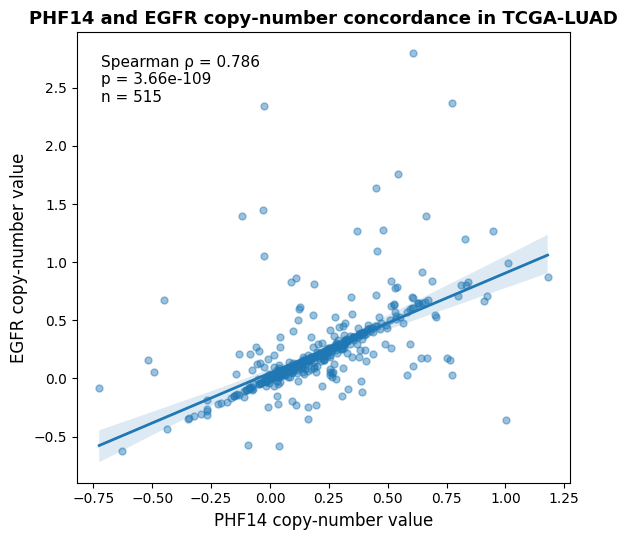

In [136]:
from scipy.stats import spearmanr
import matplotlib.pyplot as plt
import seaborn as sns

# Select paired CNV values
plot_data = cnv[["PHF14", "EGFR"]].dropna()

# Spearman correlation
rho, pval = spearmanr(
    plot_data["PHF14"],
    plot_data["EGFR"]
)

# Plot
plt.figure(figsize=(6, 5.5))

sns.regplot(
    data=plot_data,
    x="PHF14",
    y="EGFR",
    scatter_kws={
        "s": 25,
        "alpha": 0.45
    },
    line_kws={
        "linewidth": 2
    }
)

plt.xlabel("PHF14 copy-number value", fontsize=12)
plt.ylabel("EGFR copy-number value", fontsize=12)

plt.title(
    "PHF14 and EGFR copy-number concordance in TCGA-LUAD",
    fontsize=13,
    fontweight="bold"
)

plt.text(
    0.05,
    0.95,
    f"Spearman ρ = {rho:.3f}\np = {pval:.2e}\nn = {len(plot_data)}",
    transform=plt.gca().transAxes,
    ha="left",
    va="top",
    fontsize=11
)

plt.tight_layout()
plt.show()